In [1]:
import pandas as pd
import sys
import pandas as pd
# adding Folder_2 to the system path
sys.path.insert(0, "/s/chromatin/m/nobackup/ahmed/DeepPlant/")
from torch.nn.parallel import DistributedDataParallel as DDP
import torch.multiprocessing as mp
from torch.cuda import device_count
from typing import Optional, Any
from src.ddp import setup, cleanup, is_main_process
import torch.distributed as dist
from src.utils import hot_encode_sequence, create_path, save_data_to_csv
import torch
from fastprogress import progress_bar
from src.config import ExpressionConfig
from src.utils import read_json, get_device
from src.DeepPlant_expression import build_model
import numpy as np
from torch.utils.data import Dataset, DataLoader, DistributedSampler
from Bio.motifs.matrix import FrequencyPositionMatrix


In [2]:
config = ExpressionConfig(
            **read_json(
                json_path="/s/chromatin/m/nobackup/ahmed/DeepPlant/json/config_AT_expressionRC.json"
            )
        )

In [3]:
device = get_device()
model = build_model(
                args=config,
                new_model=False,
                model_path="/s/chromatin/a/nobackup/ahmed/DeepPlant/results/expression_AT/159978/model_26_03_11:12:27.pt" #'/s/chromatin/a/nobackup/ahmed/DeepPlant/results/expression_AT/803010/checkpoints/model_25_12_15:05:32.pt', #
            ).to(device)

Loading model state
Model state loaded


In [4]:
def get_gene(header):
    return header.split("_")[0]


def get_tss(header):
    return int(header.split("_")[2])
gene_df = pd.read_csv(
            "/s/chromatin/m/nobackup/ahmed/DeepPlant/data/arabidopsis/expression/expression_data_TSS_centered_2500_0_RC.csv"
        )

gene_df_desc = pd.read_csv('/s/chromatin/m/nobackup/ahmed/DeepPlant/data/arabidopsis/arabidopsis_expression_data_split.csv').drop(columns='Unnamed: 1')

gene_df["gene"] = list(map(get_gene, gene_df.header))
gene_df["tss"] = list(map(get_tss, gene_df.header))
gene_df_full = gene_df.merge(gene_df_desc,how='left',on=['gene','tss'])


In [5]:
gene_df_full

,header,sequence,gene,tss,split,chrom,strand
0,AT1G01010_1_3631,CATGTTTTTTAGTTGTGGCGAAAAATAAGAAATCCATACATCAACA...,AT1G01010,3631,train,1,1
1,AT1G01020_1_9130,ATCAAATCGACAAGTCATTTAACAGAATGTATTTCCCTCCCATTGC...,AT1G01020,9130,train,1,-1
2,AT1G01030_1_13714,AGGAAATTTTGGACCACACAATTTGTTGACACATCAGCAACCAAAC...,AT1G01030,13714,train,1,-1
3,AT1G01040_1_23121,CGCGTATTTTTTTATTTGAATTATTTGGTTTTTGGTTAGTTAACTA...,AT1G01040,23121,train,1,1
4,AT1G01050_1_33171,GTGGAAGGAAGTCTCCGAAGAGGTAAAACAAAAACCAATGATTCAT...,AT1G01050,33171,train,1,-1
...,...,...,...,...,...,...,...
32196,AT5G67390_5_26889367,AAATCATTCCTTATCGTAACATATAATTATGGATTAGTGAGTTGTA...,AT5G67390,26889367,test,5,-1
32197,AT5G67540_5_26946377,TTCTTTCATTCAAATAGAAGTTCAAGAACTCTGGTAAACTCTAACA...,AT5G67540,26946377,test,5,-1
32198,AT5G67550_5_26949184,GATATTATTGTTATCTCATTGAAGATTTTTTTTTCGTTTGTCAAAA...,AT5G67550,26949184,test,5,-1
32199,AT5G67560_5_26950106,GATTCCGTTAACACTTAGTTACCACATTAACGTTATAATATCACAA...,AT5G67560,26950106,test,5,1


# GEX metadata

In [6]:
import pandas as pd
gex_metadata = pd.read_csv('/s/chromatin/m/nobackup/ahmed/DeepPlant/Metadata/arabidopsis_expression_metadata_sorted.txt',sep='\t')
gex_metadata

,Sample,SampleName,Tissue,Ecotype,Genotype,Treatment,Project,TotalReads,UniqueMappedRatio,ReleaseDate
0,ERX1946687,Timepoint 10,rosette leaf,Col-0,--,Cold4C 3h*,PRJEB19974,16422598,0.9458,2018/7/4
1,ERX1946688,Timepoint 11,rosette leaf,Col-0,--,Cold4C 6h*,PRJEB19974,17555521,0.9478,2018/7/4
2,ERX1946689,Timepoint 12,rosette leaf,Col-0,--,Cold4C 9h*,PRJEB19974,18629695,0.9573,2018/7/4
3,ERX1946691,Timepoint 14,rosette leaf,Col-0,--,Cold4C 15h*,PRJEB19974,18690296,0.9536,2018/7/4
4,ERX1946693,Timepoint 16,rosette leaf,Col-0,--,Cold4C 21h*,PRJEB19974,17787214,0.9588,2018/7/4
...,...,...,...,...,...,...,...,...,...,...
3137,SRX7949154,se-2_RNA-seq_rp1,leaf,Col-0,--,--,PRJNA613247,23645521,0.7857,2020/3/19
3138,GSM4422802,t45 col 13,shoot tip,Col-0,wild type,45 minutes after 90 degree gravistimulation,PRJNA613599,24239134,0.9273,2020/3/25
3139,SRX145599,"ctr1-1 air 3-day, replicate 2",seedlings,Col-0,ctr1-1,--,SRP012592,30395294,0.8101,2012/10/19
3140,SRX145601,ein2 S645A air 3-day replicate 1,seedlings,Col-0,ein2,--,SRP012592,29082199,0.8418,2012/10/19


In [7]:
gex_metadata.loc[gex_metadata.SampleName=='WT rep1']

,Sample,SampleName,Tissue,Ecotype,Genotype,Treatment,Project,TotalReads,UniqueMappedRatio,ReleaseDate
869,GSM1279546,WT rep1,root,Col-0,wild type,untreated,PRJNA230565,14172032,0.8156,2015/7/22
978,GSM1390693,WT rep1,seedlings,Col-0,cR-grown WT,--,PRJNA248132,24919619,0.7452,2014/7/2
1136,GSM1603462,WT rep1,seedlings,Col-0,wild type,--,PRJNA274783,29411066,0.9338,2016/1/4
1254,GSM1858952,WT rep1,seedlings,Col-0,wild type,--,PRJNA293514,29082730,0.9264,2016/3/28
1438,SRX1657497,WT rep1,seedlings,Col-0,--,--,PRJNA316129,23276320,0.9332,2017/9/25
1567,GSM2159757,WT rep1,leaves,Col-0,wild type,--,PRJNA322179,14973560,0.9811,2017/5/30
1927,GSM2516569,WT rep1,rosette leaf,Col-0,wild type,--,PRJNA377549,16295013,0.9493,2018/2/16
2705,GSM3511858,WT rep1,Root,Col-0,Wild type,Protoplasted,PRJNA509920,261013034,0.7763,2019/9/18
2710,GSM3516768,WT rep1,14 day-old seedlings,Col-0,wild type,--,PRJNA510312,66494670,0.8329,2019/6/5
3130,GSM4404114,WT rep1,root,Col-0,wild type,--,PRJNA611622,9541020,0.9318,2020/3/11


In [8]:
gex_metadata.Tissue.unique()

array(['rosette leaf', 'flower buds', 'seedling', 'leaf', 'hypocotyl',
       'root', 'shoot', 'leaves', 'aerial seedling', '--', 'seedlings',
       'apical shoot meristem', 'cultured  cell', 'anther', 'stem',
       'seed', 'inflorescence', 'whole plant', 'shoot apex',
       'Inflorescence axis', 'carpels', 'flower', 'internode',
       'leaf blade', 'leaf petiole', 'leaf midrib', 'ovule', 'pedicel',
       'petal', 'pod', 'root apex', 'cotyledon', 'siliques', 'sepal',
       'stamen filament', 'stigma', 'rosette leaves', '10days seedlings',
       'growth points', 'flower bud', 'stamen', 'pollen grains',
       'whole seedling', '2-week seedlings', 'inflorescences', 'Leaves',
       'gynoecia', 'stamens',
       'Apical portions of plants (cut in hypocotyl)',
       '7-day-old root tips', 'leaves no. 5-6th darkened for 5 days',
       'uncovered leaves', 'Root', 'aerial part', 'root tip',
       'inflorescence meristems', 'meristems and young leaves',
       '1cm long root tips', '

# Functions

In [9]:
def scan_sequence(sequence, matrix_data, thresh):
        """
        Manually scans a sequence with a weight matrix.
        Returns: (best_score, best_start_position)
        """
        # Get motif length from the 'A' list
        motif_len = len(matrix_data["A"])
        seq_len = len(sequence)
        # Safety Check: If motif is longer than sequence, we can't scan
        if motif_len > seq_len:
            return -float("inf"), -1

        # Convert dict to easier lookup format
        # keys: A, C, G, T. values: lists of weights
        best_score = -float("inf")
        best_pos = -1
        for pos, score in matrix_data.search(
            sequence, threshold=matrix_data.max * thresh
        ):
            yield (pos, score)

        return best_pos,best_score

In [10]:
import os
from Bio import motifs
def load_motif_database(
    db_path: Optional[
        str
    ] = "/s/chromatin/m/nobackup/ahmed/DeepPlant/data/arabidopsis/PFMs",  # "/s/chromatin/a/nobackup/ahmed/AT_motifs/PFMs",
):
    motifs_dict = dict()
    for pfm_file in os.listdir(db_path):
        motifs_dict[pfm_file] = motifs.read(
            open(os.path.join(db_path, pfm_file)), "pfm"
        )
    return motifs_dict


def get_motifs(motifs_dict, background):
    pssm_dict = dict()
    for tf, motif in motifs_dict.items():
        pwm = motif.counts.normalize(pseudocounts=0.5)
        pssm = pwm.log_odds(background=background)  # this converts pfm to pssm
        pssm_dict[tf] = pssm

    return pssm_dict

In [12]:
import requests

def get_motif_name(matrix_id):
    #matrix_id = "MA1192.2"
    try:
        url = f"https://jaspar.elixir.no/api/v1/matrix/{matrix_id}"

        response = requests.get(url)
        response.raise_for_status()

        data = response.json()
        return data["name"]
    except:
        return matrix_id

In [14]:
def get_latest_motifs(motif_dict):
    latest_dict = {}
    
    for motif in motif_dict.keys():
        # Split 'MA1186.1.pfm' -> ['MA1186', '1', 'pfm']
        parts = motif.split('.')
        base_id = parts[0]
        version = int(parts[1])
        
        # If we haven't seen this base ID, or if this version is newer
        if base_id not in latest_dict or version > latest_dict[base_id]['version']:
            latest_dict[base_id] = {'version': version, 'full_name': motif}
            
    # Extract just the motif names
    #print(latest_dict)
    return {key['full_name']:motif_dict[key['full_name']] for key in latest_dict.values()}

In [15]:
def relative_to_genomic_position(rel_pos, tss, strand):
    """
    Convert relative position (0–2499) in 2500bp TSS-centered sequence
    to genomic coordinate.

    rel_pos: index in sequence (0-based)
    tss: integer TSS coordinate
    strand: '+' or '-'
    """

    center = 1250  # middle of 2500bp window

    rel_pos = int(rel_pos)
    tss = int(tss)
    strand = int(strand)

    # if strand == "+":
    #     # upstream is lower coordinate
    #     genomic_pos = tss - (center - rel_pos)
    # else:
    #     # reverse strand flips direction
    #     genomic_pos = tss + (center - rel_pos)
    genomic_pos = tss + (rel_pos - center)*strand
    return genomic_pos

In [16]:
def extract_chromosome(header):
    # Example header contains "Chr1"
    for token in header.split():
        if "Chr" in token:
            return token.strip()
    return None

In [17]:
def load_bed_for_tf(tf_name, metadata, bed_files_path):
    """
    Returns:
        bed_df (DataFrame) or None if not found
    """

    tf_rows = metadata.loc[metadata.Factor == tf_name]

    if len(tf_rows) == 0:
        return None

    bioproject, accession = tf_rows[['BioProject ID','Sample accession number']].values[0]

    hammock_path = f"{bed_files_path}/{bioproject}/hammock/"

    if not os.path.exists(hammock_path):
        return None

    files = os.listdir(hammock_path)

    for file in files:
        if ".target.all.bed" in file:
            if accession in file or tf_name in file:
                bed_file = pd.read_csv(
                    f"{hammock_path}/{file}",
                    delimiter="\t",
                    header=None
                )
                return bed_file

    return None

In [18]:
def check_peak_overlap(bed_df, chromosome, genomic_pos, window=0):
    
    overlaps = bed_df[
        (bed_df[0] == chromosome) &
        (bed_df[1] <= genomic_pos + window) &
        (bed_df[2] >= genomic_pos - window)
    ]

    return len(overlaps) > 0

In [41]:
def scan_variant_effects_from_dict(
    ref_seq,
    alt_seq,
    motif_dict,
    score_threshold=0.0,
):
    """
    Plots variant effects using raw dictionary PSSM data.

    Args:
        motif_dict: Dict of dicts, e.g. {'MotifName': {'A': [...], 'C': [...]}}
        score_threshold: The log-odds score threshold (e.g., 5.0).
                         Since your values go down to -11, 0 is a reasonable
                         start (better than random), but >5 is usually 'strong binding'.
    """

    # --- 1. Identify Variant ---
    variant_idx = -1
    min_len = min(len(ref_seq), len(alt_seq))
    for i in range(min_len):
        if ref_seq[i] != alt_seq[i]:
            variant_idx = i
            break

    if variant_idx == -1:
        if len(ref_seq) != len(alt_seq):
            variant_idx = min_len  # Handle indel at end
        else:
            # print("No variant found.")
            return

    # print(f"Variant found at index {variant_idx}")

    # --- 2. Helper: Manual PSSM Scoring ---
    def scan_sequence(sequence, matrix_data, thresh):
        """
        Manually scans a sequence with a weight matrix.
        Returns: (best_score, best_start_position)
        """
        # Get motif length from the 'A' list
        motif_len = len(matrix_data["A"])
        seq_len = len(sequence)

        # Safety Check: If motif is longer than sequence, we can't scan
        if motif_len > seq_len:
            return -1,-float("inf")

        # Convert dict to easier lookup format
        # keys: A, C, G, T. values: lists of weights

        best_score = -float("inf")
        best_pos = -1
        for pos, score in matrix_data.search(
            sequence, threshold=matrix_data.max * thresh
        ):
            return (pos, score)

        return best_pos, best_score

    # --- 3. Scan All Motifs ---
    affected_motifs = []

    for name, matrix_data in motif_dict.items():
        pos_ref, score_ref = scan_sequence(ref_seq, matrix_data, score_threshold)
        pos_alt, score_alt = scan_sequence(alt_seq, matrix_data, score_threshold)
        # Logic for Gain/Loss
        # print(score_alt,matrix_data)
        is_hit_ref = score_ref >= (matrix_data.max * score_threshold)
        is_hit_alt = score_alt >= (matrix_data.max * score_threshold)
        if is_hit_ref:
            is_hit_alt = score_alt >= (matrix_data.max * 0.5)
            if not is_hit_alt:
                affected_motifs.append((f"{name}({get_motif_name(name.split('.pfm')[0])})", "Loss", pos_ref))
        

        elif is_hit_alt:
            is_hit_ref = score_ref >= (matrix_data.max * 0.5)
            if not is_hit_ref:
                affected_motifs.append((f"{name}({get_motif_name(name.split('.pfm')[0])})", "Gain", pos_alt))
        # # Optional: Include "Change" if both are hits but score changes drastically
        # elif is_hit_ref and is_hit_alt and abs(score_ref - score_alt) > 3.0:
        #      effect = "Weaker" if score_alt < score_ref else "Stronger"
        #      affected_motifs.append((name, f"{effect} (Change)", matrix_data, pos_alt))
    #print(affected_motifs)
    return affected_motifs

In [42]:
def analyze_mutations_with_chip(
    gene,
    sum_lfc,
    ref_sequence,
    nuclt,
    gene_df_full,
    motif_dict,
    metadata,
    bed_files_path,
    mutation_threshold=0.7,
    score_threshold=0.7,
    pad=15
):
    nuc_to_index = {'A':0,'C':1,'G':2,'T':3}
    # Convert sequence to row indices
    rows = np.array([nuc_to_index[n] for n in ref_sequence])
    # Column indices
    cols = np.arange(len(ref_sequence))
    ISM_values = (sum_lfc-sum_lfc.mean(0))[rows, cols]

    results = []
    #edit_sum_lfc = sum_lfc-sum_lfc.mean(0)

    # -------------------
    # Gene information
    # -------------------
    row = gene_df_full.loc[gene_df_full.gene == gene].iloc[0]

    

    strand = str(row.strand)
    tss = int(row.tss)
    chromosome = f"Chr{str(row.chrom)}"

    # -------------------
    # Identify strong mutations
    # -------------------
    indices = np.where(ISM_values > mutation_threshold * ISM_values.max())[0]

    for pos in progress_bar(indices):
        

        mutation = nuclt[np.argmin(sum_lfc[:,pos])]#nuclt[nuc_index]


        if ref_sequence[pos] == mutation:
            continue

        # -------------------
        # Local sequence window
        # -------------------
        ref_local = ref_sequence[pos-pad:pos+pad]
        alt_local = (
            ref_sequence[pos-pad:pos] +
            mutation +
            ref_sequence[pos+1:pos+pad]
        )

        # -------------------
        # Scan motif effects
        # -------------------
        affected = scan_variant_effects_from_dict(
            ref_local,
            alt_local,
            motif_dict,
            score_threshold
        )

        if not affected:
            continue
        # -------------------
        # Convert to genomic coordinate
        # -------------------
        genomic_pos = relative_to_genomic_position(
            rel_pos=pos,
            tss=tss,
            strand=strand
        )
        # -------------------
        # Check each motif
        # -------------------
        for motif_name, effect, motif_rel_pos in affected:

            tf_name = motif_name.split("(")[1].replace(")", "")
            bed_df = load_bed_for_tf(tf_name, metadata, bed_files_path)
            

            if bed_df is None:
                peak_status = "No bed file found"
            else:
                peak_status = check_peak_overlap(
                    bed_df,
                    chromosome,
                    genomic_pos
                )

            results.append({
                "gene": gene,
                "chromosome": chromosome,
                "relative_position": pos,
                "genomic_position": genomic_pos,
                "strand": strand,
                "ref": ref_sequence[pos],
                "alt": mutation,
                "motif": tf_name,
                "effect": effect,
                "chip_peak_overlap": peak_status
            })

    return pd.DataFrame(results)

In [43]:
def nuclt_dict(sequences):
    back_freq = {"A": 0, "C": 0, "G": 0, "T": 0}
    for sequence in sequences:
        for nuclt in back_freq.keys():
            back_freq[nuclt] += sequence.count(nuclt)
    back_freq = {key: back_freq[key] / sum(back_freq.values()) for key in back_freq}
    return back_freq

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D
import matplotlib.font_manager as fm


def draw_letter(ax, letter, x, height, color):
    """
    Draw a nucleotide letter at position x.
    Positive height → upright.
    Negative height → flipped vertically (head-down).
    """

    if height == 0:
        return

    text = TextPath(
        (0, 0), letter, size=1,
        prop=fm.FontProperties(family="DejaVu Sans", weight="bold")
    )

    if height > 0:
        transform = Affine2D().scale(1, height).translate(x, 0)
    else:
        transform = ( Affine2D().scale(1, height).translate(x, 0) )

    patch = PathPatch(
        text,
        lw=0,
        fc=color,
        transform=transform + ax.transData
    )

    ax.add_patch(patch)

In [44]:
def plot_ref_alt_ism(
    gene,
    chrom,
    sum_lfc,
    ref_sequence,
    results_df,
    start=0,
    end=0
):
    sum_lfc = sum_lfc-sum_lfc.mean(0)
    letters = ['A', 'C', 'G', 'T']
    letter_to_index = {l: i for i, l in enumerate(letters)}

    colors = {
        'A': '#2ca02c',
        'C': '#1f77b4',
        'G': '#ff7f0e',
        'T': '#d62728'
    }

    mut_positions = results_df.relative_position.values
    # start = max(0, min(mut_positions) - window_padding)
    # end = min(2500, max(mut_positions) + window_padding)
    region = range(start, end)

    mutation_dict = {}
    for _, row in results_df.iterrows():
        pos = int(row.relative_position)
        alt = row.alt
        mutation_dict.setdefault(pos, []).append(alt)

    # ---------------------------
    # Create figure
    # ---------------------------
    fig = plt.figure(figsize=(18, 4))
    fig.patch.set_facecolor("white")


    gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.0)

    ax_ref = fig.add_subplot(gs[0])
    ax_alt = fig.add_subplot(gs[1], sharex=ax_ref)

    for ax in [ax_ref, ax_alt]:
        ax.set_facecolor("white")

        # Remove all default spines
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Remove ticks completely
        ax.set_xticks([])
        ax.set_yticks([])

        # Draw custom Y axis (vertical line at left)
        ax.axvline(x=0, color="black", linewidth=1.2,ymax=0.95)

        # Draw custom X axis (horizontal zero line)
        ax.axhline(y=0, color="black", linewidth=1.0)
    # ---------------------------
    # Plot reference
    # ---------------------------
    for i, pos in enumerate(region):
        ref_base = ref_sequence[pos]
        idx = letter_to_index[ref_base]
        value = sum_lfc[idx, pos]

        draw_letter(ax_ref, ref_base, i, value, colors[ref_base])

    # ---------------------------
    # Plot alternate
    # ---------------------------
    for i, pos in enumerate(region):

        if pos not in mutation_dict:
            ref_base = ref_sequence[pos]
            idx = letter_to_index[ref_base]
            value = sum_lfc[idx, pos]
            draw_letter(ax_alt, ref_base, i, value, colors[ref_base])
        else:
            print(pos,mutation_dict[pos])
            # for alt_base in mutation_dict[pos]:
            #     idx = letter_to_index[alt_base]
            #     value = sum_lfc[idx, pos]
            #     draw_letter(ax_alt, alt_base, i, value, colors[alt_base])
            #alt_base = mutation_dict[pos][0]
            if len(mutation_dict[pos])>1:
                idx = sum_lfc[:, pos].argmin()#letter_to_index[alt_base]
                alt_base = letters[idx]
            else:
                alt_base = mutation_dict[pos][0]
                idx = letter_to_index[alt_base]
            value = sum_lfc[idx, pos]
            draw_letter(ax_alt, alt_base, i, value, colors[alt_base])

    # ---------------------------
    # Highlight mutation
    # ---------------------------
    for pos in set(mut_positions):
        ax_ref.axvspan(pos - start , pos - start + 0.75,ymax=0.9,
                       color='pink', alpha=0.3)
        ax_alt.axvspan(pos - start , pos - start + 0.75,ymin=-0.9,
                       color='pink', alpha=0.3)

    # ---------------------------
    # Scale Y consistently
    # ---------------------------
    sub_scores = sum_lfc[:, start:end]
    ymin = np.min(sub_scores)
    ymax = np.max(sub_scores)

    pad = 0.05 * (ymax - ymin)

    ax_ref.set_ylim(ymin - pad, ymax + pad)
    ax_alt.set_ylim(ymin - pad, ymax + pad)
    ax_alt.set_xlim(0, end - start)

    # ---------------------------
    # Titles and annotations
    # ---------------------------

    # Left labels
    fig.text(0.02, 0.8, "Reference allele",
             ha="left", fontsize=13)

    fig.text(0.02, 0.35, "Alternative allele",
             ha="left", fontsize=13)

    # Variant text (top right)
    variant_text = f"chr4: 13,019,190 > 13,019,358 ({gene})"
    fig.text(0.98, 0.85, variant_text,
             ha="right", fontsize=14)


    # Min / Max text (right middle)
    fig.text(0.98, 0.4,
             "ISM",
             ha="right", fontsize=12)
    plt.tight_layout()
    plt.show()


In [24]:
metadata = pd.read_csv('/s/chromatin/m/nobackup/ahmed/DeepPlant/data/arabidopsis/metadata/AT_Metadata.csv')
bed_files_path = '/s/chromatin/b/nobackup/deepplant/Data/arabidopsis_thaliana/Chiphub_bedfile'
motifs_dict = load_motif_database()
motifs_dict = get_latest_motifs(motifs_dict)
back_freq = nuclt_dict(gene_df_full.sequence.values.tolist()) #{"A": 0.25, "C": 0.25, "G": 0.25, "T": 0.25}
pssm_dict_jaspar = get_motifs(motifs_dict, back_freq)

# AT4G25470 gene (CBF2 / DREB1C) / Cold-stress

In [ ]:
gene = "AT4G25470"
header = gene_df_full.loc[gene_df_full.gene==gene].header.values[0].__str__()
sequence = gene_df_full.loc[gene_df_full.gene==gene].sequence.values[0].__str__()
strand = gene_df_full.loc[gene_df_full.gene==gene].strand.values[0].__str__()
tss = gene_df_full.loc[gene_df_full.gene==gene].tss.values[0].__str__()
chrom = gene_df_full.loc[gene_df_full.gene==gene].chrom.values[0].__str__()
gene_df_full.loc[gene_df_full.gene==gene]

,header,sequence,gene,tss,split,chrom,strand
29219,AT4G25470_4_13016235,TGATAATCCAGATTATTATTAGACAAGTAGCGAAGGGACGGTGAAC...,AT4G25470,13016235,test,4,-1


In [26]:
gene_output = np.load(f"/s/chromatin/m/nobackup/ahmed/DeepPlant/data/arabidopsis/expression/{gene_df_full.loc[gene_df_full.gene==gene].header.values[0]}.npy")
gene_output.argmax(),gex_metadata.iloc[gene_output.argmax()],np.argsort(gene_output)[-15:]

(2897,
 Sample                              GSM3714862
 SampleName           TSS-Seq in WT cold - rep1
 Tissue                         14day seedlings
 Ecotype                                  Col-0
 Genotype                             wild type
 Treatment             4C cold treatment for 3h
 Project                            PRJNA531657
 TotalReads                            44040519
 UniqueMappedRatio                       0.8893
 ReleaseDate                         2019/10/29
 Name: 2897, dtype: object,
 array([2483, 2484, 2489, 2495, 2997, 2496, 2488, 2492, 2485, 2494, 2851,
        2490, 2487, 2895, 2897]))

In [27]:
nuclt = ["A", "C", "G", "T"]
sum_lfc = torch.zeros(4, 2500, 3142).to(device)
ref_allele = sequence
eps = 1.0
ref_input = torch.from_numpy(hot_encode_sequence(sequence=ref_allele, length_after_padding=2500)).unsqueeze(0).to(device)
with torch.no_grad():
    model.eval()
    ref_labels = model(input=ref_input)
    for idx in progress_bar(range(len(ref_allele))):
        for j, nucl in enumerate(nuclt):
            if ref_allele[idx] != nucl:
                mut_allele = ref_allele[:idx] + nucl + ref_allele[idx + 1 :]
                mut_input = (
                    torch.tensor(
                        hot_encode_sequence(mut_allele), dtype=torch.float
                    )
                    .unsqueeze(0)
                    .to(device)
                )
                mut_label = model(input=mut_input)
                sum_lfc[j, idx] = (torch.log(mut_label + eps) - torch.log(ref_labels + eps))
sum_lfc = sum_lfc.cpu().numpy()

In [28]:
nuc_to_index = {'A':0,'C':1,'G':2,'T':3}
# Convert sequence to row indices
rows = np.array([nuc_to_index[n] for n in ref_allele])

# Column indices
cols = np.arange(len(sequence))

# Cold-stress

### Cold 1-hour

In [29]:
exp_id = 279
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = (sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))[rows, cols]
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.5*ISM_values.max())[0])

Sample                SRX1881751
SampleName           Cold 1 hour
Tissue                    leaves
Ecotype                    Col-0
Genotype                      --
Treatment                   cold
Project              PRJNA324514
TotalReads              39782302
UniqueMappedRatio         0.9034
ReleaseDate            2016/8/26
Name: 279, dtype: object
gene expression is  124.22935
most important positions are  [1145 1146 1147 1148 1149 1150 1151 1153 1189 1199 1220 1363 1364]


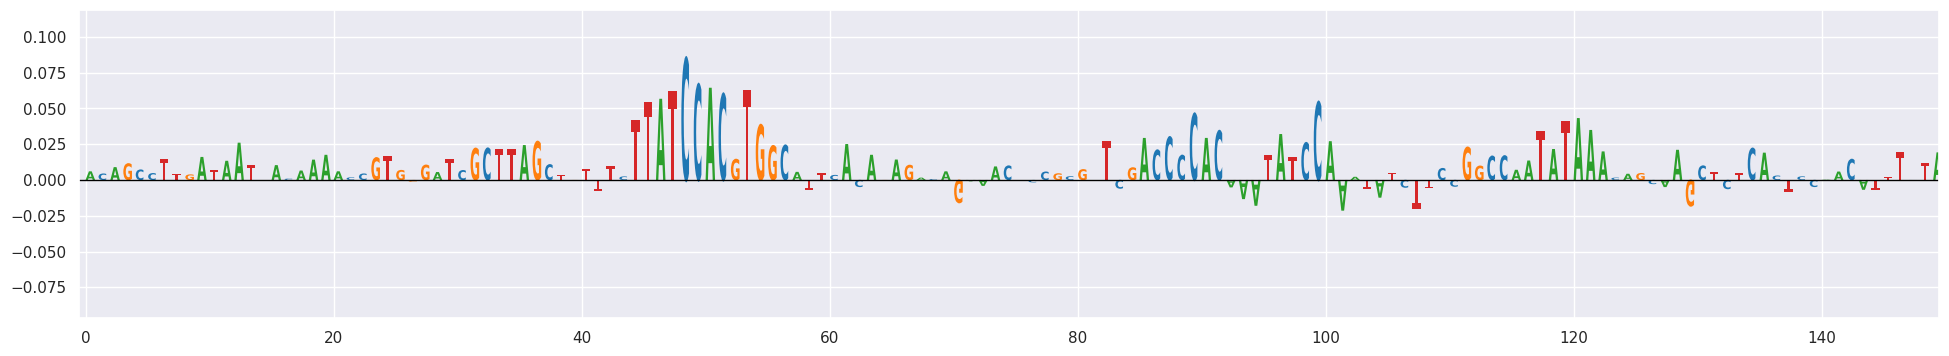

In [30]:
n0 = 1100
n1 = 1250
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

### Cold 3-hours

In [31]:
exp_id = 282
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = (sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))[rows, cols]
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.5*ISM_values.max())[0])

Sample                 SRX1881753
SampleName           Cold 3 hours
Tissue                     leaves
Ecotype                     Col-0
Genotype                       --
Treatment                    cold
Project               PRJNA324514
TotalReads               27297258
UniqueMappedRatio          0.9087
ReleaseDate             2016/8/26
Name: 282, dtype: object
gene expression is  117.30453
most important positions are  [1145 1146 1147 1148 1149 1150 1151 1153 1189 1190 1195 1196 1197 1198
 1200 1202 1205]


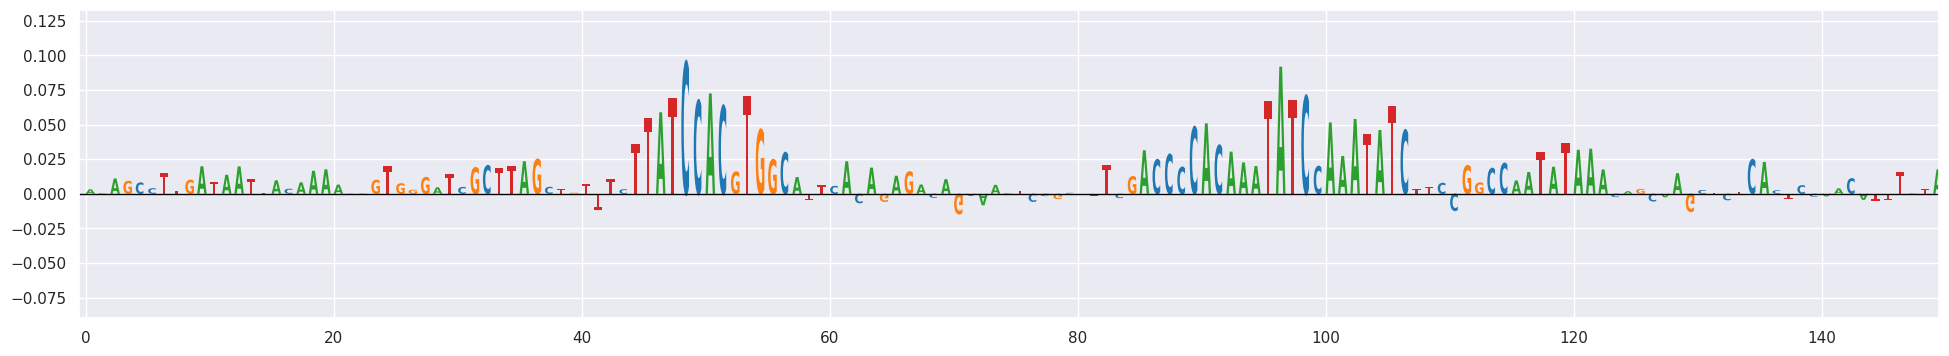

In [32]:
n0 = 1100
n1 = 1250
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

### Cold 6-hours

In [33]:
exp_id = 283
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = (sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))[rows, cols]
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.5*ISM_values.max())[0])

Sample                 SRX1881761
SampleName           Cold 6 hours
Tissue                     leaves
Ecotype                     Col-0
Genotype                       --
Treatment                    cold
Project               PRJNA324514
TotalReads               25601261
UniqueMappedRatio          0.9113
ReleaseDate             2016/8/26
Name: 283, dtype: object
gene expression is  105.09169
most important positions are  [1147 1148 1149 1150 1153 1195 1196 1197 1198 1200 1202 1203 1204 1205
 1206]


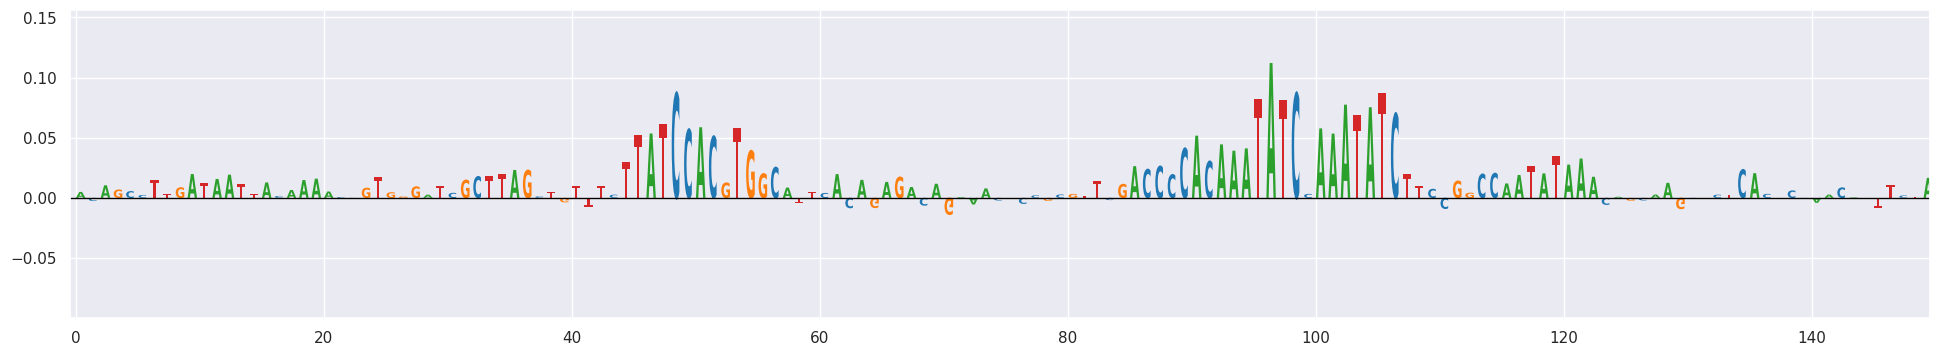

In [34]:
n0 = 1100
n1 = 1250
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

### Cold 12-hours

In [35]:
exp_id = 280
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = (sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))[rows, cols]
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.5*ISM_values.max())[0])

Sample                  SRX1881839
SampleName           Cold 12 hours
Tissue                      leaves
Ecotype                      Col-0
Genotype                        --
Treatment                     cold
Project                PRJNA324514
TotalReads                36203588
UniqueMappedRatio           0.9146
ReleaseDate              2016/8/26
Name: 280, dtype: object
gene expression is  27.860933
most important positions are  [1146 1147 1148 1149 1150 1151 1153 1195 1196 1197 1198 1200 1202 1203
 1204 1205 1206]


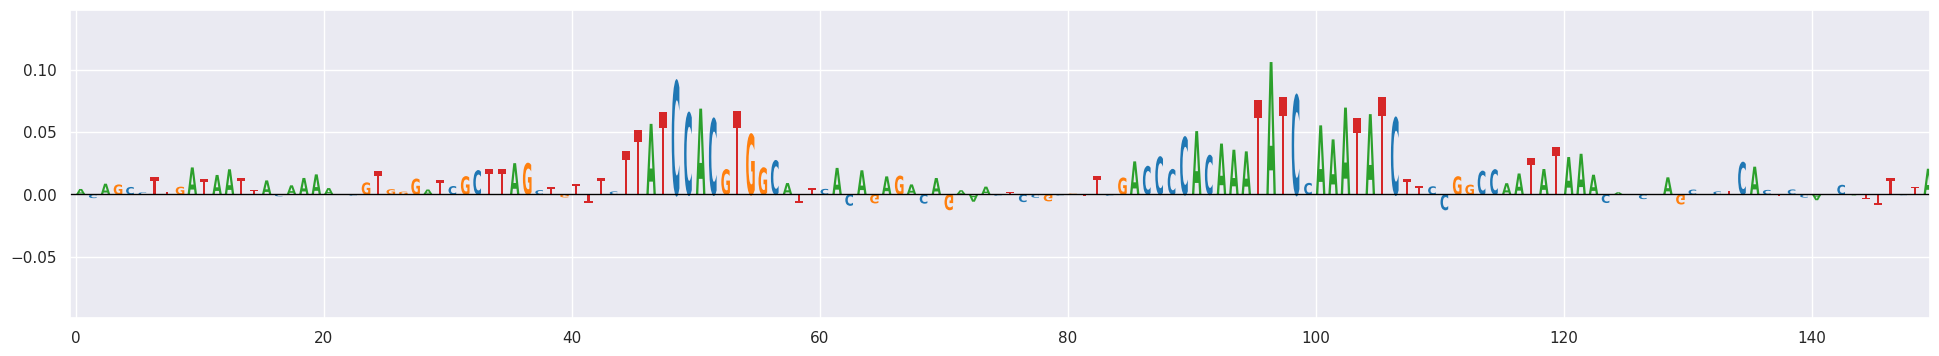

In [36]:
n0 = 1100
n1 = 1250
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

### Cold 24-hours

In [37]:
exp_id = 281
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = (sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))[rows, cols]
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.5*ISM_values.max())[0])

Sample                  SRX1881841
SampleName           Cold 24 hours
Tissue                      leaves
Ecotype                      Col-0
Genotype                        --
Treatment                     cold
Project                PRJNA324514
TotalReads                43221967
UniqueMappedRatio           0.8688
ReleaseDate              2016/8/26
Name: 281, dtype: object
gene expression is  26.716082
most important positions are  [1145 1146 1147 1148 1149 1150 1151 1153 1154 1190 1195 1196 1197 1198
 1200 1202 1203 1204 1205 1206]


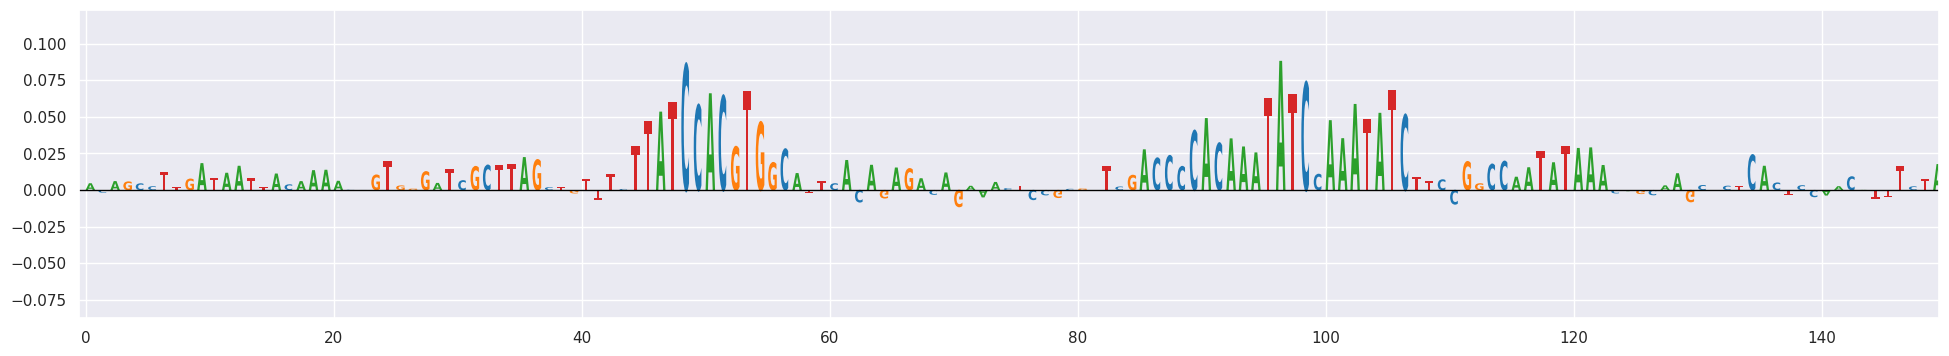

In [38]:
n0 = 1100
n1 = 1250
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

# Heat

### Heat 1-hour

In [39]:
exp_id = 284
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = (sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))[rows, cols]
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.5*ISM_values.max())[0])

Sample                SRX1881868
SampleName           Heat 1 hour
Tissue                    leaves
Ecotype                    Col-0
Genotype                      --
Treatment                   heat
Project              PRJNA324514
TotalReads              13822746
UniqueMappedRatio         0.8176
ReleaseDate            2016/8/26
Name: 284, dtype: object
gene expression is  7.8063126
most important positions are  [1145 1146 1147 1148 1149 1150 1151 1153 1189 1199 1363 1364 1367]


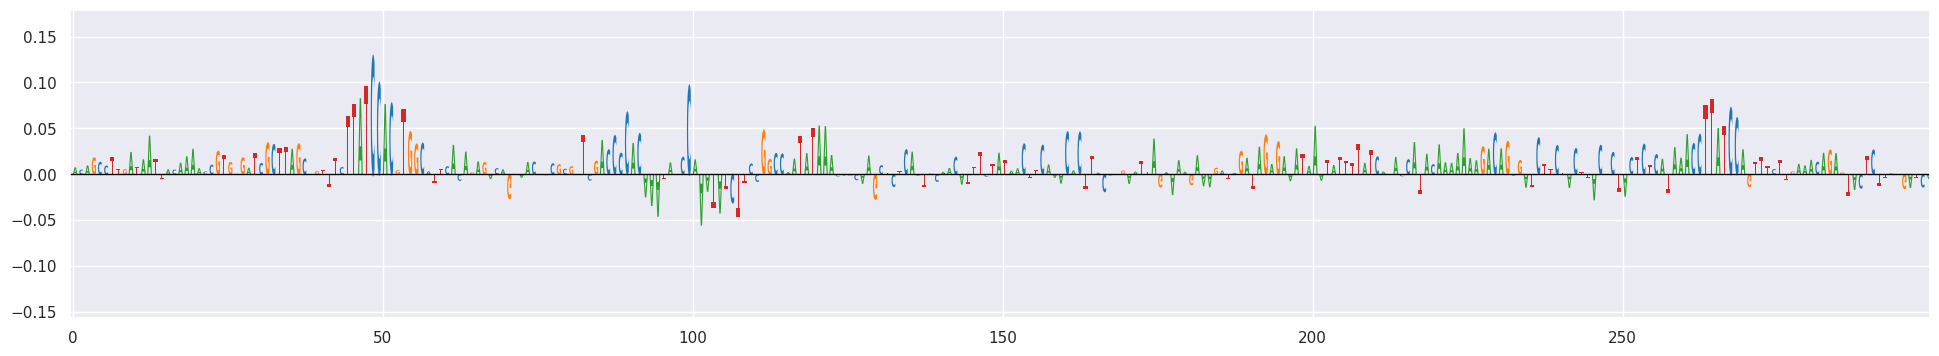

In [40]:
n0 = 1100
n1 = 1400
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

### Heat 12-hours

In [41]:
exp_id = 285
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = (sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))[rows, cols]
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.5*ISM_values.max())[0])

Sample                  SRX1881889
SampleName           Heat 12 hours
Tissue                      leaves
Ecotype                      Col-0
Genotype                        --
Treatment                     heat
Project                PRJNA324514
TotalReads                16739193
UniqueMappedRatio           0.8006
ReleaseDate              2016/8/26
Name: 285, dtype: object
gene expression is  3.747776
most important positions are  [1145 1146 1147 1148 1149 1150 1151 1153 1196 1197 1198 1363 1364 1367]


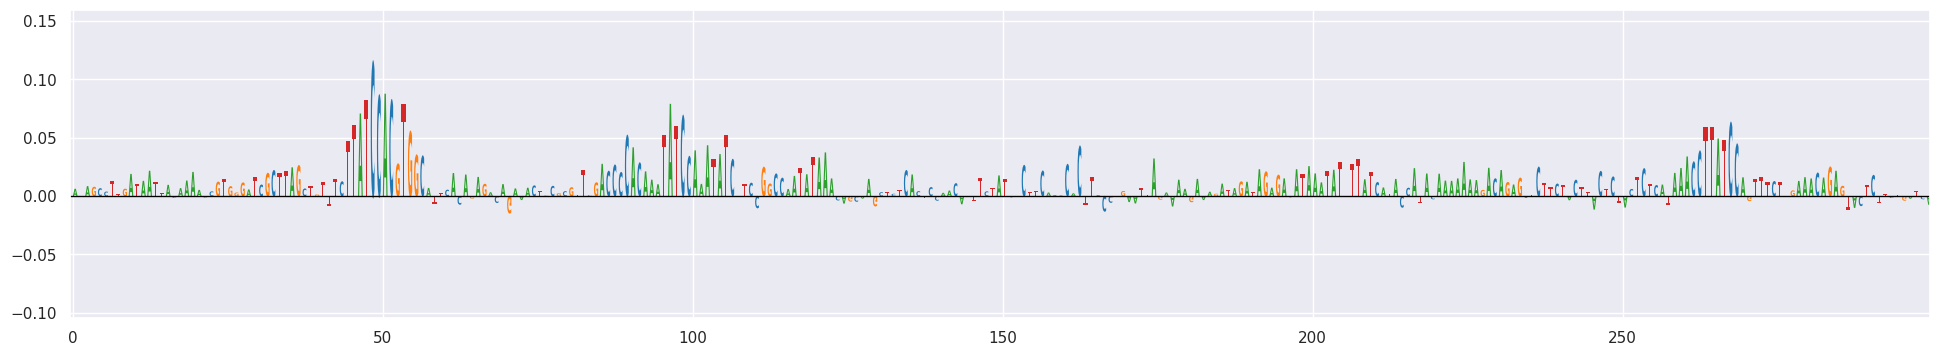

In [42]:
n0 = 1100
n1 = 1400
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

### Heat 24-hours

In [43]:
exp_id = 286
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = (sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))[rows, cols]
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.5*ISM_values.max())[0])

Sample                  SRX1881908
SampleName           Heat 24 hours
Tissue                      leaves
Ecotype                      Col-0
Genotype                        --
Treatment                     heat
Project                PRJNA324514
TotalReads                16442117
UniqueMappedRatio           0.8158
ReleaseDate              2016/8/26
Name: 286, dtype: object
gene expression is  5.0984807
most important positions are  [1145 1146 1147 1148 1149 1150 1151 1153 1196 1198 1363 1364 1367]


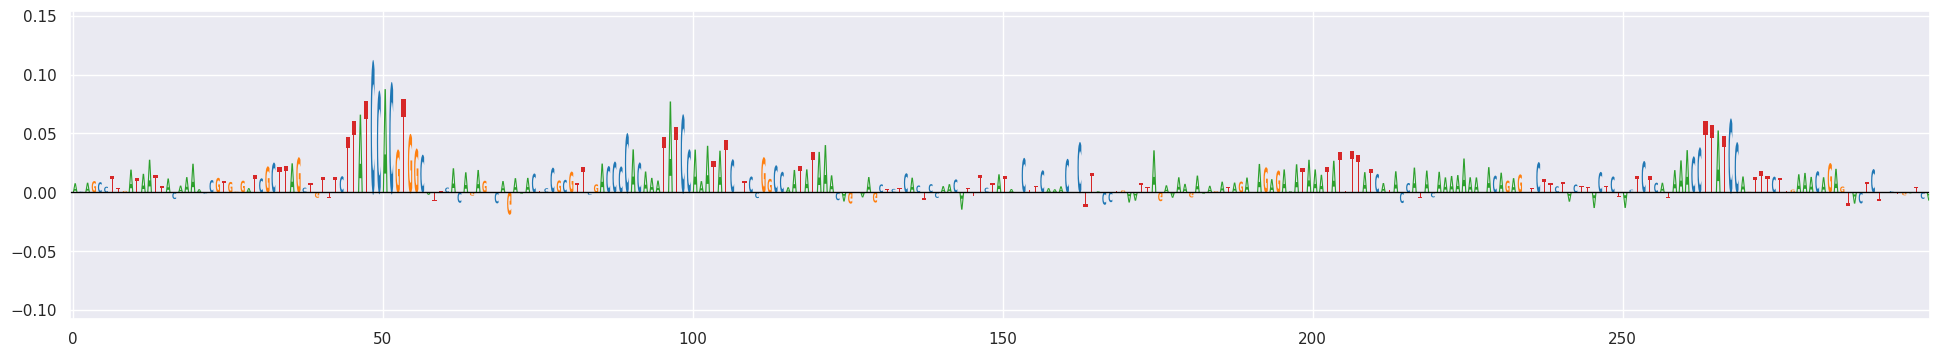

In [44]:
n0 = 1100
n1 = 1400
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

# Wounding

### Wounding 1-hour

In [45]:
exp_id = 287
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = (sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))[rows, cols]
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.5*ISM_values.max())[0])

Sample                    SRX1882433
SampleName           Wounding 1 hour
Tissue                        leaves
Ecotype                        Col-0
Genotype                          --
Treatment                   wounding
Project                  PRJNA324514
TotalReads                  16104177
UniqueMappedRatio             0.8435
ReleaseDate                2016/8/26
Name: 287, dtype: object
gene expression is  13.132495
most important positions are  [1077 1144 1145 1146 1147 1148 1149 1150 1151 1153 1189 1199 1217 1219
 1220 1221 1260 1262 1300 1324 1336 1362 1363 1364 1367 1368]


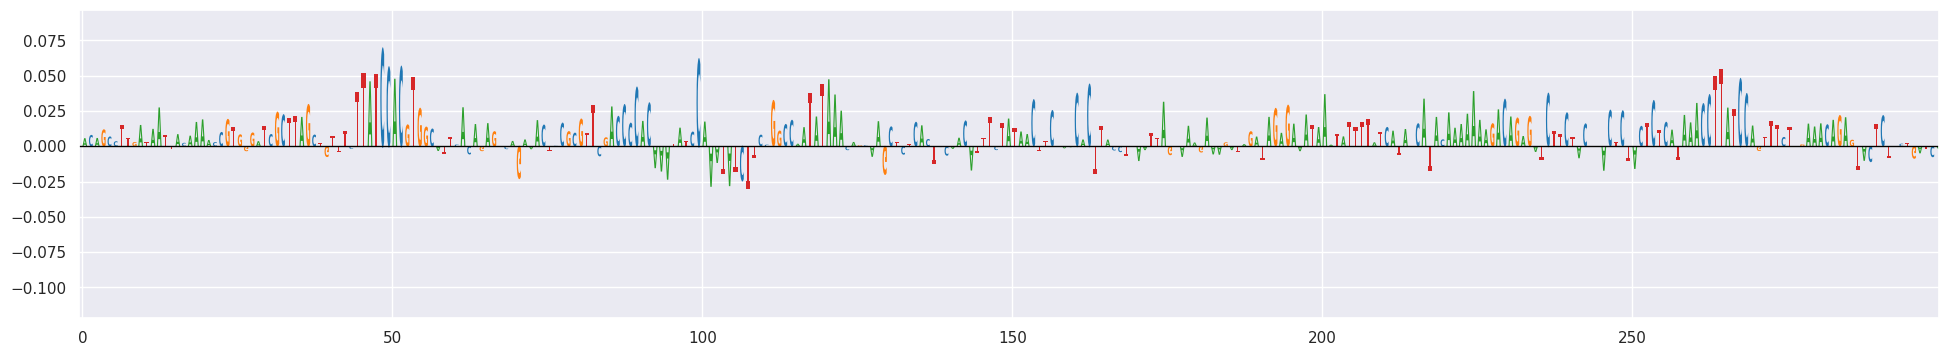

In [46]:
n0 = 1100
n1 = 1400
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

### Wounding 12-hours 

In [47]:
exp_id = 288
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = (sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))[rows, cols]
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.5*ISM_values.max())[0])

Sample                      SRX1882503
SampleName           Wounding 12 hours
Tissue                          leaves
Ecotype                          Col-0
Genotype                            --
Treatment                     wounding
Project                    PRJNA324514
TotalReads                    19322440
UniqueMappedRatio               0.8328
ReleaseDate                  2016/8/26
Name: 288, dtype: object
gene expression is  15.329292
most important positions are  [1145 1146 1147 1148 1149 1150 1151 1153 1190 1195 1196 1197 1198 1200
 1202 1203 1204 1205 1206]


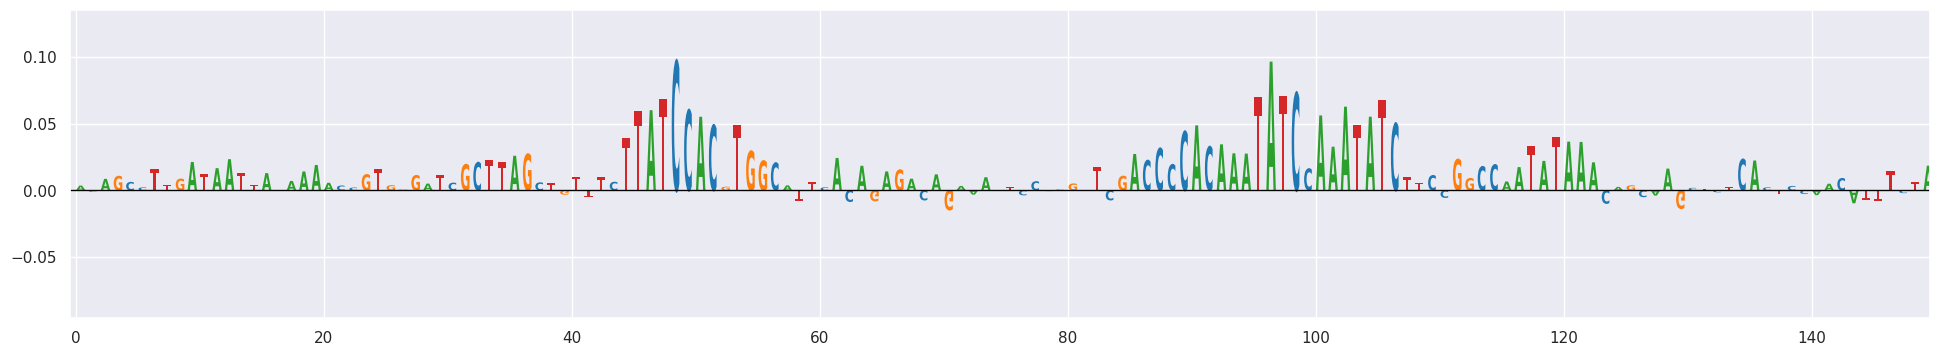

In [48]:
n0 = 1100
n1 = 1250
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

### Wounding 24-hours

In [49]:
exp_id = 289
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = (sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))[rows, cols]
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.5*ISM_values.max())[0])

Sample                      SRX1882526
SampleName           Wounding 24 hours
Tissue                          leaves
Ecotype                          Col-0
Genotype                            --
Treatment                     wounding
Project                    PRJNA324514
TotalReads                    17097515
UniqueMappedRatio               0.8442
ReleaseDate                  2016/8/26
Name: 289, dtype: object
gene expression is  23.329725
most important positions are  [1144 1145 1146 1147 1148 1149 1150 1151 1153 1189 1199 1363 1364]


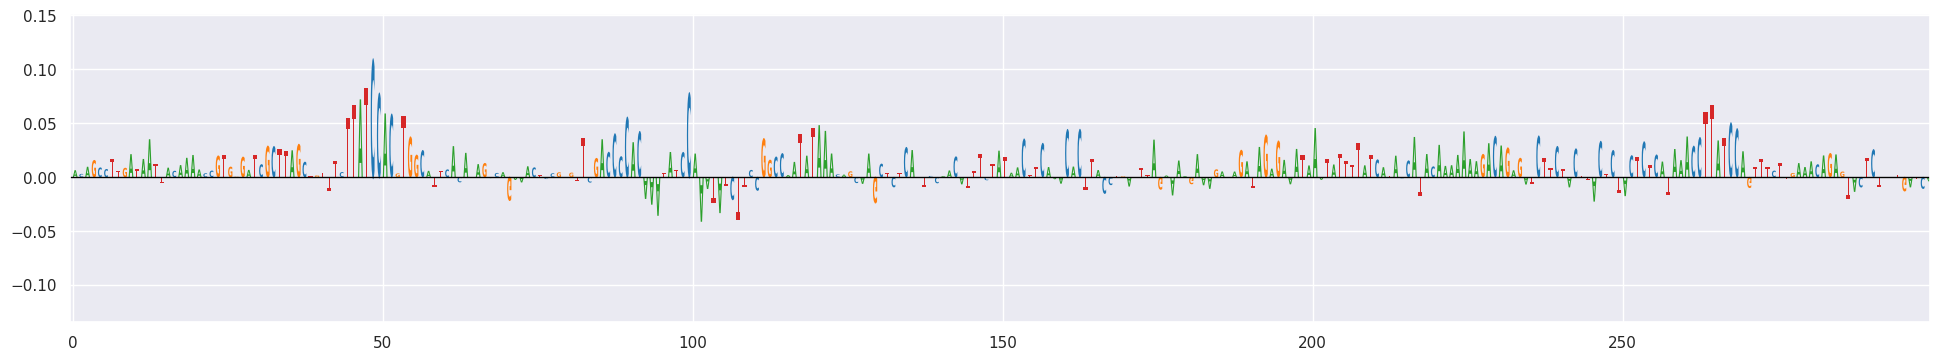

In [50]:
n0 = 1100
n1 = 1400
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

# Drought

### Short-term drought

In [51]:
exp_id = 2504
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = (sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))[rows, cols]#((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.5*ISM_values.max())[0])

Sample                       SRX4508528
SampleName                       WT_LD2
Tissue                           leaves
Ecotype                           Col-0
Genotype                      Wild type
Treatment            short-term drought
Project                     PRJNA484081
TotalReads                     22080931
UniqueMappedRatio                0.9006
ReleaseDate                    2019/9/2
Name: 2504, dtype: object
gene expression is  1.3942425
most important positions are  [1145 1146 1147 1148 1149 1150 1151 1153 1199 1363 1364 1367]


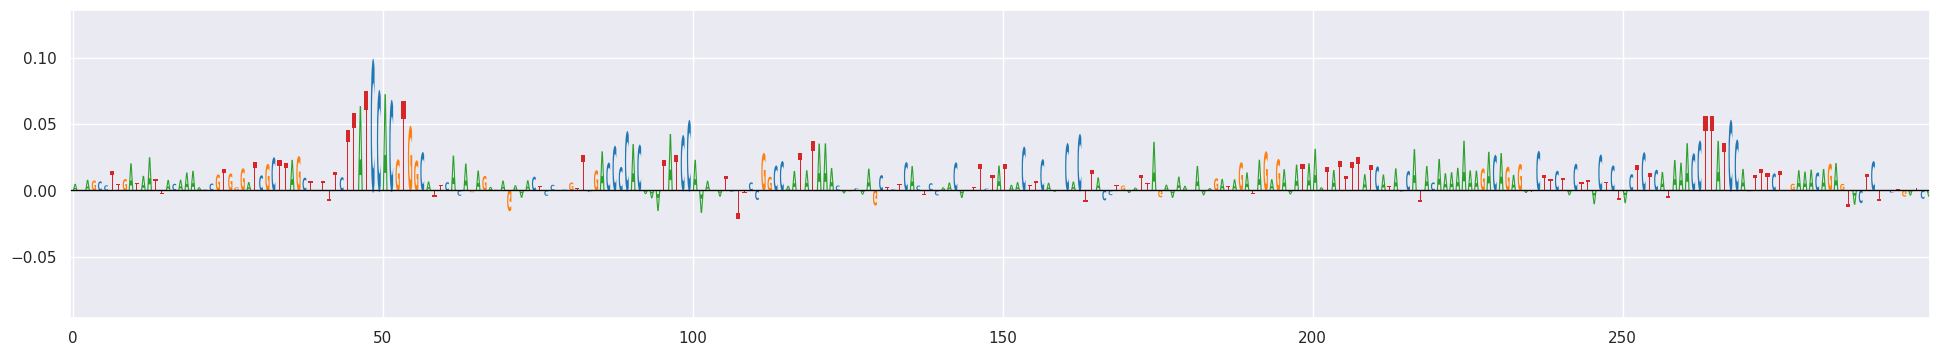

In [52]:
n0 = 1100
n1 = 1400
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

### Long-term drought

In [53]:
exp_id = 2503
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = (sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))[rows, cols]#((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values>0.5*ISM_values.max())[0])

Sample                      SRX4508504
SampleName                       WTLL1
Tissue                          leaves
Ecotype                          Col-0
Genotype                     Wild type
Treatment            long-term drought
Project                    PRJNA484081
TotalReads                    24821051
UniqueMappedRatio               0.8863
ReleaseDate                   2019/9/2
Name: 2503, dtype: object
gene expression is  18.924513
most important positions are  [1145 1147 1148 1149 1150 1151 1153 1195 1196 1197 1198 1200 1202 1203
 1204 1205 1206 1262]


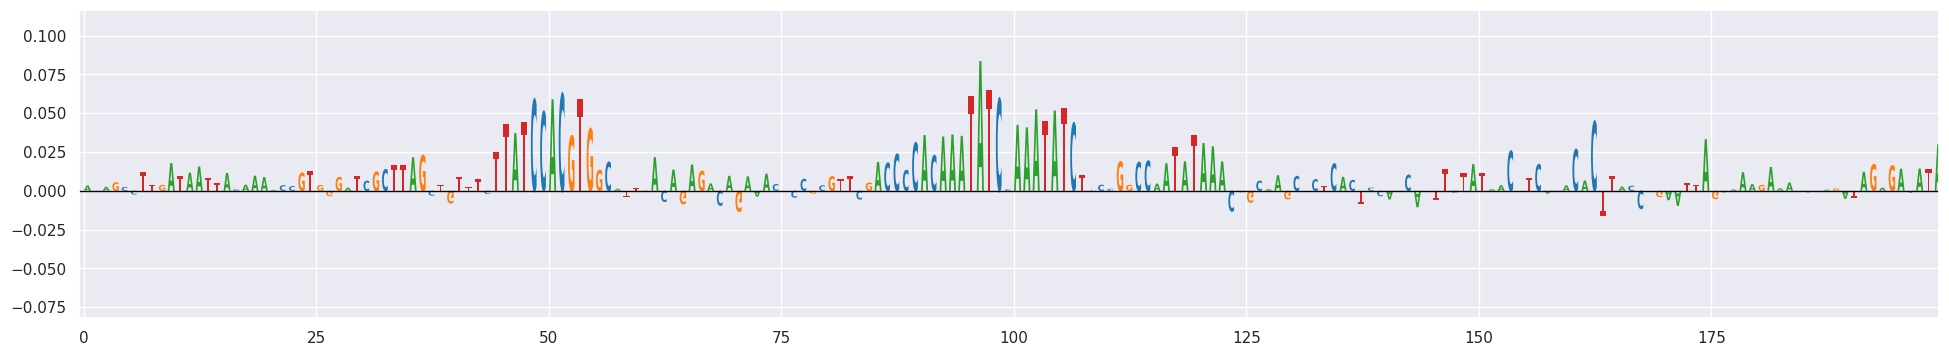

In [54]:
n0 = 1100
n1 = 1300
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

# Repressors under Normal condition

In [ ]:
exp_id = 611#1567#3130#750#1927
print(gex_metadata.iloc[exp_id])
print('gene expression is ',gene_output[exp_id])
ISM_values = (sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))[rows, cols]
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
print('most important positions are ',np.where(ISM_values<0.6*ISM_values.min())[0])

Sample                 GSM2516569
SampleName                WT rep1
Tissue               rosette leaf
Ecotype                     Col-0
Genotype                wild type
Treatment                      --
Project               PRJNA377549
TotalReads               16295013
UniqueMappedRatio          0.9493
ReleaseDate             2018/2/16
Name: 1927, dtype: object
gene expression is  4.935356
most important positions are  [1277 2026 2028 2029 2030 2031 2032]


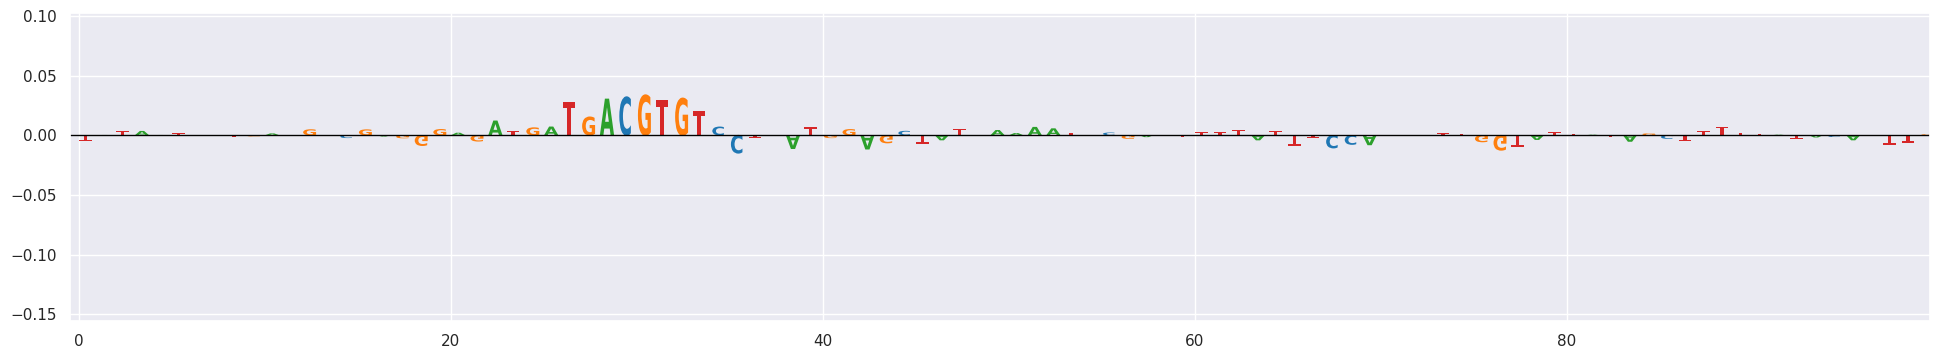

In [56]:
n0 = 2000
n1 = 2100
exp_sum_lfc = sum_lfc[:,:, exp_id]-sum_lfc[:,:, exp_id].mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = -exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = -np.max(exp_sum_lfc)
ymax = -np.min(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

In [ ]:
tfs_set = set()
for tf,motif in pssm_dict_jaspar.items():
    for pos,score in scan_sequence(ref_allele[2020:2040],motif,0.8):
        print(tf,get_motif_name(tf.split('.pfm')[0]),pos,len(motif['A']))
        tfs_set.add(get_motif_name(tf.split('.pfm')[0]))
        break


UN0689.2.pfm NFYB2 -12 6
MA1786.2.pfm NAC019 -14 7
MA1044.2.pfm NAC92 -14 8
MA0930.3.pfm ABF3 8 7
MA1787.2.pfm NAC047 -16 10
MA1785.2.pfm NAC018 -16 10
MA1425.2.pfm HYH 6 7
UN0854.1.pfm BZIP17 8 5
MA1745.2.pfm BZIP63 6 8
MA2389.1.pfm GBF1 8 7
MA0588.2.pfm TGA1 4 8
UN0865.1.pfm KNAT3 6 4
MA0937.1.pfm NAC055 -14 8
UN0867.1.pfm UN0867.1 6 8
UN0866.1.pfm KNAT6 6 4


In [71]:
for tf in tfs_set:
    for idx,row in metadata.loc[(metadata["Factor"].str.startswith(tf))&(metadata.Mutant=='WT')].iterrows():
        if (check_peak_overlap(load_bed_for_tf(row.Factor,metadata,bed_files_path),'Chr4',gene_df.loc[gene_df.gene==gene].tss.values[0]-780,20)):
            print(row.Factor)

ABF3
ABF3
NFYB2
NFYB2


# General mutations

In [45]:
general_sum_lfc = sum_lfc.mean(axis=2)
ISM_values = (general_sum_lfc-general_sum_lfc.mean(0))[rows, cols]
#np.argsort((((sum_lfc[:,:,exp_id]-sum_lfc[:,:,exp_id].mean(0))*hot_encode_sequence(ref_allele)).max(axis=0)))[-100:]
np.where(ISM_values>0.4*ISM_values.max())

(array([1144, 1145, 1146, 1147, 1148, 1149, 1150, 1151, 1153, 1189, 1195,
        1196, 1197, 1198, 1200, 1205, 1219, 1262, 1336, 1363, 1364, 1367]),)

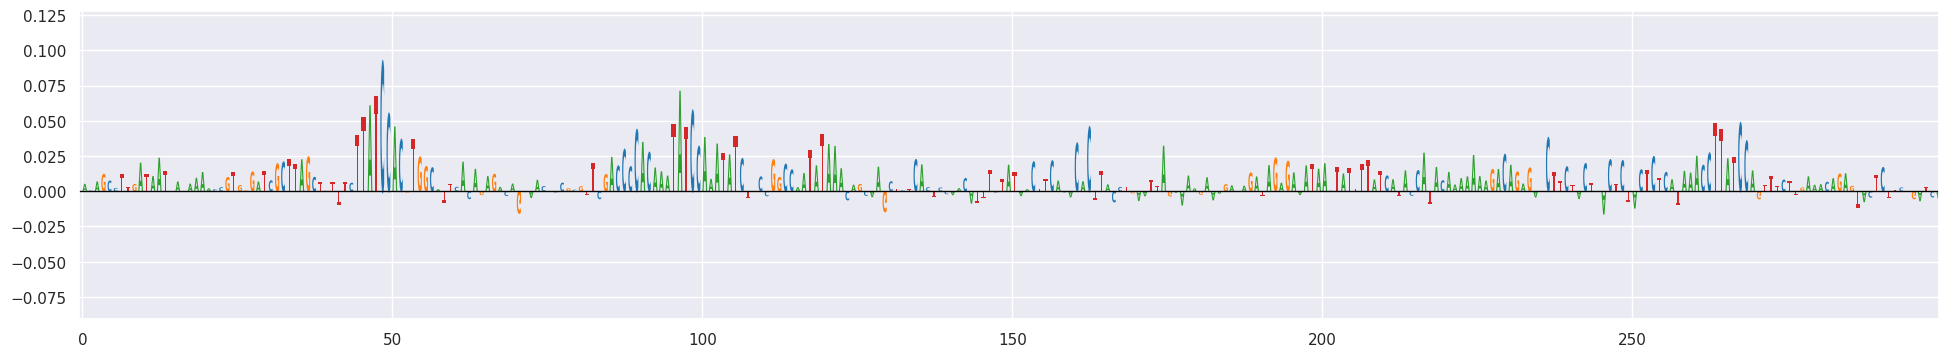

In [46]:
n0 = 1100
n1 = 1400
exp_sum_lfc = general_sum_lfc-general_sum_lfc.mean(0)
import numpy as np
region = np.arange(n0,n1)
letters = ['A', 'C', 'G', 'T']
letter_to_index = {l: i for i, l in enumerate(letters)}
nuc_colors = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
fig,ax = plt.subplots(1,1,figsize=(24,4))
for i, pos in enumerate(region):
    ref_base = ref_allele[pos]
    idx = letter_to_index.get(ref_base)
    if idx is not None:
        value = exp_sum_lfc[idx, pos]
        draw_letter(ax, ref_base, i, value, nuc_colors.get(ref_base, 'black'))
# correct limits
ax.set_xlim(-0.5, len(region)-0.5)

# use the correct matrix
#sub_scores = exp_sum_lfc[:, n0:n1]
ymin = np.min(exp_sum_lfc)
ymax = np.max(exp_sum_lfc)

pad = 0.01 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

ax.axhline(0, color="black", lw=1)

# General important mutations

In [47]:
general_sum_lfc = sum_lfc.mean(axis=2)

In [48]:
results_df = analyze_mutations_with_chip(
    gene=gene,
    sum_lfc=general_sum_lfc,
    ref_sequence=ref_allele,
    nuclt=nuclt,
    gene_df_full=gene_df_full,
    motif_dict=pssm_dict_jaspar,
    metadata=metadata,
    bed_files_path=bed_files_path,
    mutation_threshold=0.4,
    score_threshold=0.8,
    pad=10
)
results_df.to_csv(f"/s/chromatin/a/nobackup/ahmed/DeepPlant/results/ISM/{gene}.csv",index=False)
results_df.head()

,gene,chromosome,relative_position,genomic_position,strand,ref,alt,motif,effect,chip_peak_overlap
0,AT4G25470,Chr4,1144,13016341,-1,T,G,ARR1,Gain,True
1,AT4G25470,Chr4,1144,13016341,-1,T,G,NID1,Loss,No bed file found
2,AT4G25470,Chr4,1144,13016341,-1,T,G,AT5G04760,Loss,True
3,AT4G25470,Chr4,1144,13016341,-1,T,G,DIV1,Loss,No bed file found
4,AT4G25470,Chr4,1144,13016341,-1,T,G,KUA1,Loss,No bed file found


In [49]:
results_df.chip_peak_overlap.value_counts()

chip_peak_overlap
No bed file found    136
True                  72
False                 59
Name: count, dtype: int64

In [50]:
results_df.loc[results_df.chip_peak_overlap==True]

,gene,chromosome,relative_position,genomic_position,strand,ref,alt,motif,effect,chip_peak_overlap
0,AT4G25470,Chr4,1144,13016341,-1,T,G,ARR1,Gain,True
2,AT4G25470,Chr4,1144,13016341,-1,T,G,AT5G04760,Loss,True
9,AT4G25470,Chr4,1145,13016340,-1,T,G,AT5G04760,Loss,True
16,AT4G25470,Chr4,1146,13016339,-1,A,T,AT5G04760,Loss,True
26,AT4G25470,Chr4,1147,13016338,-1,T,C,AT5G04760,Loss,True
...,...,...,...,...,...,...,...,...,...,...
254,AT4G25470,Chr4,1367,13016118,-1,C,A,AT5G04760,Loss,True
256,AT4G25470,Chr4,1367,13016118,-1,C,A,AT1G74840,Loss,True
258,AT4G25470,Chr4,1367,13016118,-1,C,A,AT5G56840,Loss,True
259,AT4G25470,Chr4,1367,13016118,-1,C,A,AT1G19000,Loss,True


In [51]:
results_df.loc[results_df.effect=='Loss'].motif.unique()

array(['NID1', 'AT5G04760', 'DIV1', 'KUA1', 'AT4G09450', 'BZIP28',
       'BZIP16', 'DPBF3', 'BZIP63', 'BZIP68', 'bHLH74', 'MYC3', 'PIF1',
       'BHLH72', 'PIF3', 'HBI1', 'BIM2', 'ILR3', 'BPE', 'ABF2', 'PIF4',
       'PIF5', 'BEE2', 'URI', 'NF-YB9', 'UN0823.1', 'BIM3', 'ABI5',
       'ABF3', 'BZIP17', 'ABF4', 'GBF2', 'GBF1', 'ABF1', 'SPT', 'GBF3',
       'NFYC2', 'KAN1', 'CCA1', 'AT2G28920', 'RVE7L', 'RVE8', 'RVE1',
       'LHY', 'ZAT7', 'AT5G04390', 'GATA9', 'GATA4', 'GATA15', 'GATA8',
       'GATA12', 'YAB4', 'TRP5', 'AT3G10580', 'AT1G74840', 'AT5G56840',
       'AT1G19000', 'STKL2', 'AT2G38090', 'MA1681.2', 'AT5G05790',
       'AT5G61620'], dtype=object)

In [54]:
results_df.relative_position.unique()

array([1144, 1145, 1146, 1147, 1148, 1149, 1150, 1151, 1153, 1189, 1195,
       1196, 1197, 1200, 1205, 1262, 1336, 1363, 1364, 1367])

1144 ['G']
1145 ['G']
1146 ['T']
1147 ['C']
1148 ['G']
1149 ['G', 'G', 'G', 'G', 'G', 'G', 'G']
1150 ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C']
1151 ['G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G']
1153 ['G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G']
1195 ['G']
1196 ['G']
1197 ['A']
1200 ['G', 'G']
1205 ['C', 'C', 'C']
1363 ['G', 'G', 'G', 'G', 'G']
1364 ['A', 'A', 'A', 'A', 'A']
1367 ['A', 'A', 'A', 'A', 'A']


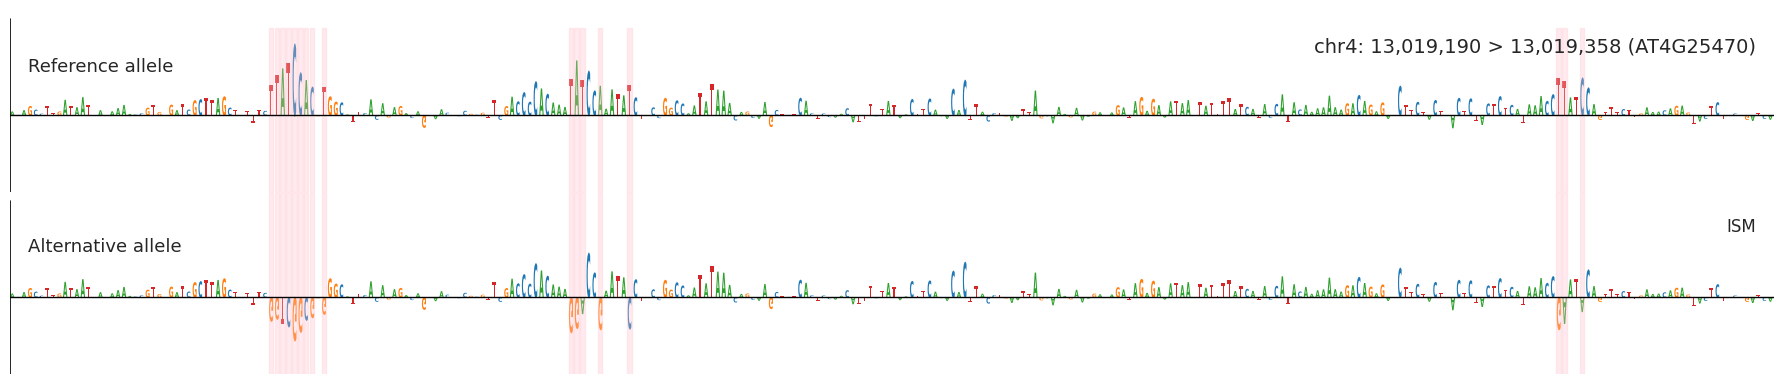

In [55]:
#results_df = pd.read_csv(f"/s/chromatin/a/nobackup/ahmed/DeepPlant/results/ISM/{gene}_new.csv")
loss_df = results_df.loc[
    (results_df.chip_peak_overlap == True) &
    (results_df.effect == 'Loss')
]

#loss_df = loss_df.loc[(loss_df.relative_position<1500)&(loss_df.relative_position>900)]

plot_ref_alt_ism(
    gene=gene,
    chrom='chr4',
    sum_lfc=general_sum_lfc,
    ref_sequence=ref_allele,
    results_df=loss_df,
    start=1100,
    end=1400
)

# Mutations for cold

In [56]:
gex_metadata.iloc[279]

Sample                SRX1881751
SampleName           Cold 1 hour
Tissue                    leaves
Ecotype                    Col-0
Genotype                      --
Treatment                   cold
Project              PRJNA324514
TotalReads              39782302
UniqueMappedRatio         0.9034
ReleaseDate            2016/8/26
Name: 279, dtype: object

In [57]:
results_df = analyze_mutations_with_chip(
    gene=gene,
    sum_lfc=sum_lfc[:,:,279],
    ref_sequence=ref_allele,
    nuclt=nuclt,
    gene_df_full=gene_df_full,
    motif_dict=pssm_dict_jaspar,
    metadata=metadata,
    bed_files_path=bed_files_path,
    mutation_threshold=0.4,
    score_threshold=0.8,
    pad=10
)
results_df.to_csv(f"/s/chromatin/a/nobackup/ahmed/DeepPlant/results/ISM/{gene}_cold_1h.csv",index=False)
results_df.head()

,gene,chromosome,relative_position,genomic_position,strand,ref,alt,motif,effect,chip_peak_overlap
0,AT4G25470,Chr4,1144,13016341,-1,T,G,ARR1,Gain,True
1,AT4G25470,Chr4,1144,13016341,-1,T,G,NID1,Loss,No bed file found
2,AT4G25470,Chr4,1144,13016341,-1,T,G,AT5G04760,Loss,True
3,AT4G25470,Chr4,1144,13016341,-1,T,G,DIV1,Loss,No bed file found
4,AT4G25470,Chr4,1144,13016341,-1,T,G,KUA1,Loss,No bed file found


In [58]:
results_df.relative_position.unique()

array([1144, 1145, 1146, 1147, 1148, 1149, 1150, 1151, 1153, 1154, 1189,
       1199, 1217, 1260, 1262, 1324, 1363, 1364, 1367, 1368])

In [59]:
results_df.loc[
    (results_df.chip_peak_overlap == True) &
    (results_df.effect == 'Loss')
]

,gene,chromosome,relative_position,genomic_position,strand,ref,alt,motif,effect,chip_peak_overlap
2,AT4G25470,Chr4,1144,13016341,-1,T,G,AT5G04760,Loss,True
9,AT4G25470,Chr4,1145,13016340,-1,T,G,AT5G04760,Loss,True
16,AT4G25470,Chr4,1146,13016339,-1,A,T,AT5G04760,Loss,True
26,AT4G25470,Chr4,1147,13016338,-1,T,C,AT5G04760,Loss,True
33,AT4G25470,Chr4,1148,13016337,-1,C,G,AT5G04760,Loss,True
...,...,...,...,...,...,...,...,...,...,...
279,AT4G25470,Chr4,1368,13016117,-1,C,G,AT5G04760,Loss,True
281,AT4G25470,Chr4,1368,13016117,-1,C,G,AT1G74840,Loss,True
283,AT4G25470,Chr4,1368,13016117,-1,C,G,AT5G56840,Loss,True
284,AT4G25470,Chr4,1368,13016117,-1,C,G,AT1G19000,Loss,True


1144 ['G']
1145 ['G']
1146 ['T']
1147 ['C']
1148 ['G']
1149 ['G', 'G', 'G', 'G', 'G', 'G', 'G']
1150 ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C']
1151 ['G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G']
1153 ['G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G']
1154 ['T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T']
1363 ['G', 'G', 'G', 'G', 'G']
1364 ['A', 'A', 'A', 'A', 'A']
1367 ['A', 'A', 'A', 'A', 'A']
1368 ['G', 'G', 'G', 'G', 'G']


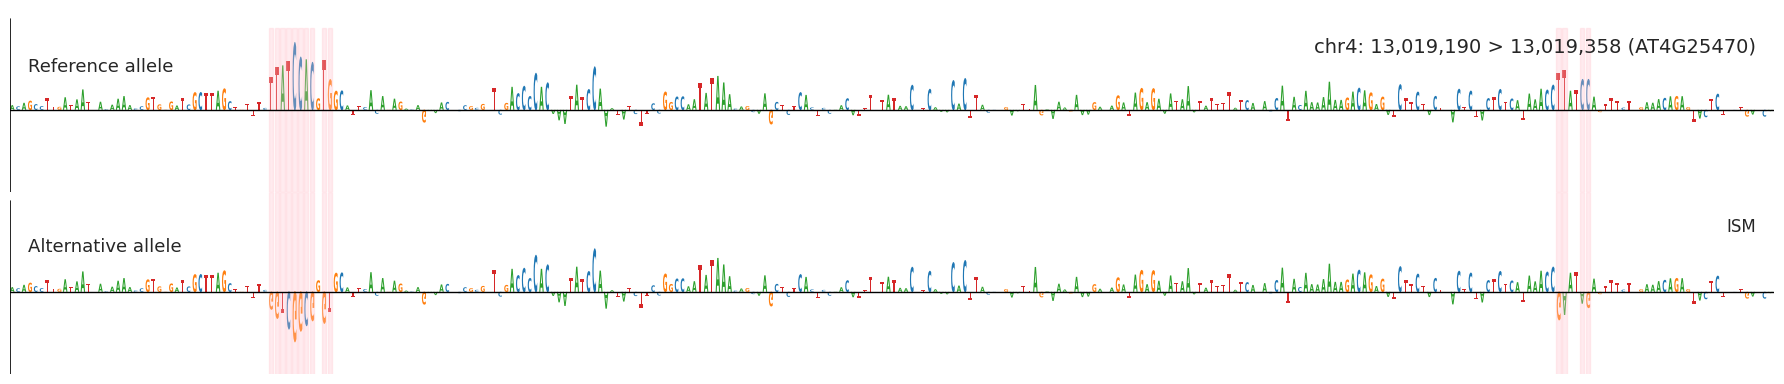

In [60]:
#results_df = pd.read_csv(f"/s/chromatin/a/nobackup/ahmed/DeepPlant/results/ISM/{gene}_new.csv")
loss_df = results_df.loc[
    (results_df.chip_peak_overlap == True) &
    (results_df.effect == 'Loss')
]

loss_df = loss_df.loc[(loss_df.relative_position<1500)]

plot_ref_alt_ism(
    gene=gene,
    chrom='chr4',
    sum_lfc=sum_lfc[:,:,279]-sum_lfc[:,:,279].mean(0),
    ref_sequence=ref_allele,
    results_df=loss_df,
    start=1100,
    end=1400
)

In [61]:
gex_metadata.iloc[282]

Sample                 SRX1881753
SampleName           Cold 3 hours
Tissue                     leaves
Ecotype                     Col-0
Genotype                       --
Treatment                    cold
Project               PRJNA324514
TotalReads               27297258
UniqueMappedRatio          0.9087
ReleaseDate             2016/8/26
Name: 282, dtype: object

In [62]:
results_df = analyze_mutations_with_chip(
    gene=gene,
    sum_lfc=sum_lfc[:,:,282],
    ref_sequence=ref_allele,
    nuclt=nuclt,
    gene_df_full=gene_df_full,
    motif_dict=pssm_dict_jaspar,
    metadata=metadata,
    bed_files_path=bed_files_path,
    mutation_threshold=0.4,
    score_threshold=0.8,
    pad=10
)
results_df.to_csv(f"/s/chromatin/a/nobackup/ahmed/DeepPlant/results/ISM/{gene}_cold_3h.csv",index=False)
results_df.head()

,gene,chromosome,relative_position,genomic_position,strand,ref,alt,motif,effect,chip_peak_overlap
0,AT4G25470,Chr4,1145,13016340,-1,T,G,NID1,Loss,No bed file found
1,AT4G25470,Chr4,1145,13016340,-1,T,G,GATA4,Gain,False
2,AT4G25470,Chr4,1145,13016340,-1,T,G,GATA15,Gain,False
3,AT4G25470,Chr4,1145,13016340,-1,T,G,AT5G04760,Loss,True
4,AT4G25470,Chr4,1145,13016340,-1,T,G,GATA8,Gain,No bed file found


In [63]:
results_df.chip_peak_overlap.value_counts()

chip_peak_overlap
No bed file found    146
True                  88
False                 65
Name: count, dtype: int64

In [64]:
results_df.loc[results_df.chip_peak_overlap==True]

,gene,chromosome,relative_position,genomic_position,strand,ref,alt,motif,effect,chip_peak_overlap
3,AT4G25470,Chr4,1145,13016340,-1,T,G,AT5G04760,Loss,True
10,AT4G25470,Chr4,1146,13016339,-1,A,T,AT5G04760,Loss,True
20,AT4G25470,Chr4,1147,13016338,-1,T,C,AT5G04760,Loss,True
27,AT4G25470,Chr4,1148,13016337,-1,C,G,AT5G04760,Loss,True
45,AT4G25470,Chr4,1149,13016336,-1,C,G,AT5G04760,Loss,True
...,...,...,...,...,...,...,...,...,...,...
285,AT4G25470,Chr4,1364,13016121,-1,T,A,AT5G04760,Loss,True
287,AT4G25470,Chr4,1364,13016121,-1,T,A,AT1G74840,Loss,True
290,AT4G25470,Chr4,1364,13016121,-1,T,A,AT5G56840,Loss,True
291,AT4G25470,Chr4,1364,13016121,-1,T,A,AT1G19000,Loss,True


In [65]:
results_df.loc[
    (results_df.chip_peak_overlap == True) &
    (results_df.effect == 'Loss')
].motif.unique()

array(['AT5G04760', 'PIF1', 'PIF3', 'BIM2', 'PIF4', 'PIF5', 'ABI5',
       'ABF3', 'ABF4', 'GBF2', 'ABF1', 'GBF3', 'NFYC2', 'CCA1', 'RVE1',
       'LHY', 'AT1G74840', 'AT5G56840', 'AT1G19000', 'AT5G61620'],
      dtype=object)

1145 ['G']
1146 ['T']
1147 ['C']
1148 ['G']
1149 ['G', 'G', 'G', 'G', 'G', 'G', 'G']
1150 ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C']
1151 ['G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G']
1153 ['G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G']
1154 ['T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T']
1195 ['G']
1196 ['G']
1197 ['A']
1200 ['G', 'G']
1202 ['C', 'C']
1203 ['C', 'C', 'C']
1204 ['T', 'T', 'T']
1205 ['C', 'C', 'C']
1206 ['T', 'T', 'T']
1363 ['G', 'G', 'G', 'G', 'G']
1364 ['A', 'A', 'A', 'A', 'A']


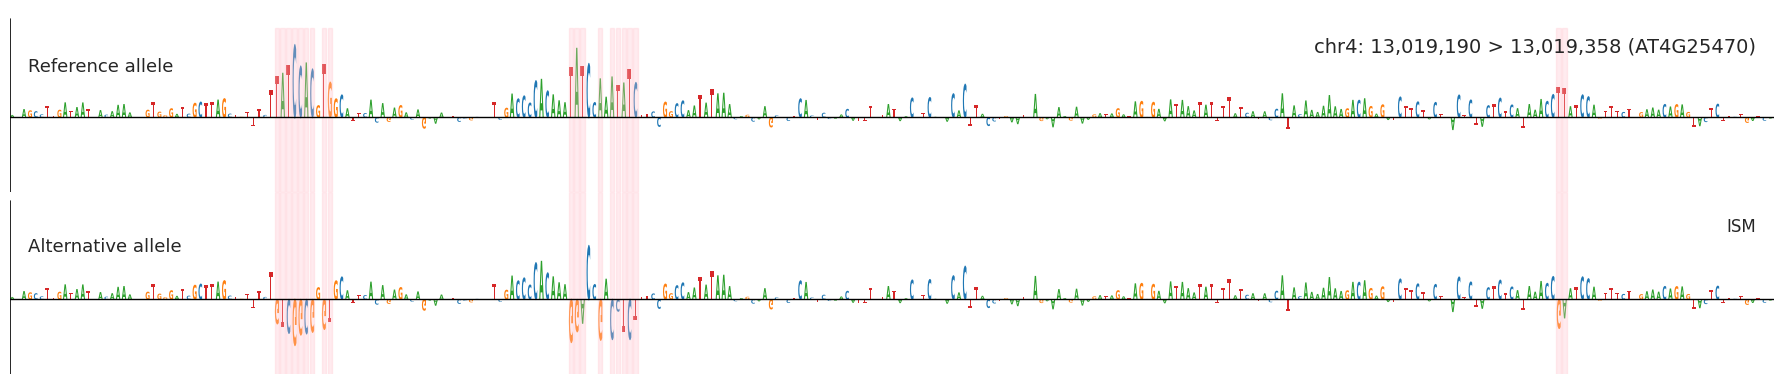

In [66]:
#results_df = pd.read_csv(f"/s/chromatin/a/nobackup/ahmed/DeepPlant/results/ISM/{gene}_new.csv")
loss_df = results_df.loc[
    (results_df.chip_peak_overlap == True) &
    (results_df.effect == 'Loss')
]

#loss_df = loss_df.loc[(loss_df.relative_position<1500)&(loss_df.relative_position>900)]

plot_ref_alt_ism(
    gene=gene,
    chrom='chr4',
    sum_lfc=sum_lfc[:,:,282],
    ref_sequence=ref_allele,
    results_df=loss_df,
    start=1100,
    end=1400
)

In [67]:
gex_metadata.iloc[283]

Sample                 SRX1881761
SampleName           Cold 6 hours
Tissue                     leaves
Ecotype                     Col-0
Genotype                       --
Treatment                    cold
Project               PRJNA324514
TotalReads               25601261
UniqueMappedRatio          0.9113
ReleaseDate             2016/8/26
Name: 283, dtype: object

In [68]:
results_df = analyze_mutations_with_chip(
    gene=gene,
    sum_lfc=sum_lfc[:,:,283],
    ref_sequence=ref_allele,
    nuclt=nuclt,
    gene_df_full=gene_df_full,
    motif_dict=pssm_dict_jaspar,
    metadata=metadata,
    bed_files_path=bed_files_path,
    mutation_threshold=0.4,
    score_threshold=0.8,
    pad=10
)
results_df.to_csv(f"/s/chromatin/a/nobackup/ahmed/DeepPlant/results/ISM/{gene}_cold_6h.csv",index=False)
results_df.head()

,gene,chromosome,relative_position,genomic_position,strand,ref,alt,motif,effect,chip_peak_overlap
0,AT4G25470,Chr4,1145,13016340,-1,T,G,NID1,Loss,No bed file found
1,AT4G25470,Chr4,1145,13016340,-1,T,G,GATA4,Gain,False
2,AT4G25470,Chr4,1145,13016340,-1,T,G,GATA15,Gain,False
3,AT4G25470,Chr4,1145,13016340,-1,T,G,AT5G04760,Loss,True
4,AT4G25470,Chr4,1145,13016340,-1,T,G,GATA8,Gain,No bed file found


In [69]:
results_df.chip_peak_overlap.value_counts()

chip_peak_overlap
No bed file found    116
True                  67
False                 48
Name: count, dtype: int64

In [70]:
results_df.loc[results_df.chip_peak_overlap==True]

,gene,chromosome,relative_position,genomic_position,strand,ref,alt,motif,effect,chip_peak_overlap
3,AT4G25470,Chr4,1145,13016340,-1,T,G,AT5G04760,Loss,True
10,AT4G25470,Chr4,1146,13016339,-1,A,T,AT5G04760,Loss,True
20,AT4G25470,Chr4,1147,13016338,-1,T,C,AT5G04760,Loss,True
27,AT4G25470,Chr4,1148,13016337,-1,C,G,AT5G04760,Loss,True
45,AT4G25470,Chr4,1149,13016336,-1,C,G,AT5G04760,Loss,True
...,...,...,...,...,...,...,...,...,...,...
223,AT4G25470,Chr4,1205,13016280,-1,T,C,LHY,Loss,True
224,AT4G25470,Chr4,1205,13016280,-1,T,C,CCA1,Loss,True
228,AT4G25470,Chr4,1206,13016279,-1,C,G,RVE1,Loss,True
229,AT4G25470,Chr4,1206,13016279,-1,C,G,LHY,Loss,True


In [71]:
results_df.loc[
    (results_df.chip_peak_overlap == True) &
    (results_df.effect == 'Loss')
].motif.unique()

array(['AT5G04760', 'PIF1', 'PIF3', 'BIM2', 'PIF4', 'PIF5', 'ABI5',
       'ABF3', 'ABF4', 'GBF2', 'ABF1', 'GBF3', 'NFYC2', 'CCA1', 'RVE1',
       'LHY'], dtype=object)

1145 ['G']
1146 ['T']
1147 ['C']
1148 ['G']
1149 ['G', 'G', 'G', 'G', 'G', 'G', 'G']
1150 ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C']
1151 ['G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G']
1153 ['G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G']
1195 ['G']
1196 ['G']
1197 ['A']
1200 ['G', 'G']
1201 ['T', 'T']
1202 ['C', 'C']
1203 ['C', 'C', 'C']
1204 ['T', 'T', 'T']
1205 ['C', 'C', 'C']
1206 ['G', 'G', 'G']


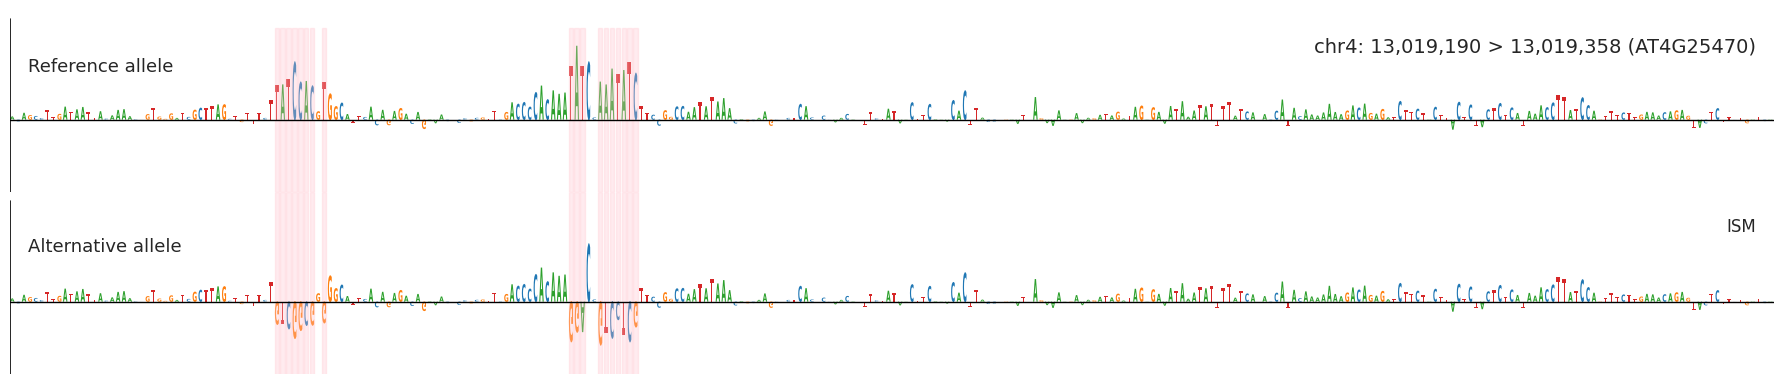

In [72]:
#results_df = pd.read_csv(f"/s/chromatin/a/nobackup/ahmed/DeepPlant/results/ISM/{gene}_new.csv")
loss_df = results_df.loc[
    (results_df.chip_peak_overlap == True) &
    (results_df.effect == 'Loss')
]

#loss_df = loss_df.loc[(loss_df.relative_position<1500)&(loss_df.relative_position>900)]

plot_ref_alt_ism(
    gene=gene,
    chrom='chr4',
    sum_lfc=sum_lfc[:,:,283]-sum_lfc[:,:,283].mean(0),
    ref_sequence=ref_allele,
    results_df=loss_df,
    start=1100,
    end=1400
)

In [73]:
gex_metadata.iloc[280]

Sample                  SRX1881839
SampleName           Cold 12 hours
Tissue                      leaves
Ecotype                      Col-0
Genotype                        --
Treatment                     cold
Project                PRJNA324514
TotalReads                36203588
UniqueMappedRatio           0.9146
ReleaseDate              2016/8/26
Name: 280, dtype: object

In [74]:
results_df = analyze_mutations_with_chip(
    gene=gene,
    sum_lfc=sum_lfc[:,:,280],
    ref_sequence=ref_allele,
    nuclt=nuclt,
    gene_df_full=gene_df_full,
    motif_dict=pssm_dict_jaspar,
    metadata=metadata,
    bed_files_path=bed_files_path,
    mutation_threshold=0.4,
    score_threshold=0.8,
    pad=10
)
results_df.to_csv(f"/s/chromatin/a/nobackup/ahmed/DeepPlant/results/ISM/{gene}_cold_12h.csv",index=False)
results_df.head()

,gene,chromosome,relative_position,genomic_position,strand,ref,alt,motif,effect,chip_peak_overlap
0,AT4G25470,Chr4,1145,13016340,-1,T,G,NID1,Loss,No bed file found
1,AT4G25470,Chr4,1145,13016340,-1,T,G,GATA4,Gain,False
2,AT4G25470,Chr4,1145,13016340,-1,T,G,GATA15,Gain,False
3,AT4G25470,Chr4,1145,13016340,-1,T,G,AT5G04760,Loss,True
4,AT4G25470,Chr4,1145,13016340,-1,T,G,GATA8,Gain,No bed file found


In [75]:
results_df.loc[results_df.chip_peak_overlap==True]

,gene,chromosome,relative_position,genomic_position,strand,ref,alt,motif,effect,chip_peak_overlap
3,AT4G25470,Chr4,1145,13016340,-1,T,G,AT5G04760,Loss,True
10,AT4G25470,Chr4,1146,13016339,-1,A,T,AT5G04760,Loss,True
20,AT4G25470,Chr4,1147,13016338,-1,T,C,AT5G04760,Loss,True
27,AT4G25470,Chr4,1148,13016337,-1,C,G,AT5G04760,Loss,True
45,AT4G25470,Chr4,1149,13016336,-1,C,G,AT5G04760,Loss,True
...,...,...,...,...,...,...,...,...,...,...
262,AT4G25470,Chr4,1205,13016280,-1,T,C,LHY,Loss,True
263,AT4G25470,Chr4,1205,13016280,-1,T,C,CCA1,Loss,True
267,AT4G25470,Chr4,1206,13016279,-1,C,G,RVE1,Loss,True
268,AT4G25470,Chr4,1206,13016279,-1,C,G,LHY,Loss,True


In [76]:
results_df.relative_position.unique()

array([1145, 1146, 1147, 1148, 1149, 1150, 1151, 1153, 1154, 1189, 1190,
       1195, 1196, 1197, 1198, 1200, 1201, 1202, 1203, 1204, 1205, 1206,
       1262])

1145 ['G']
1146 ['T']
1147 ['C']
1148 ['G']
1149 ['G', 'G', 'G', 'G', 'G', 'G', 'G']
1150 ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C']
1151 ['G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G']
1153 ['G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G']
1154 ['T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T']
1195 ['G']
1196 ['G']
1197 ['A']
1200 ['G', 'G']
1201 ['T', 'T']
1202 ['C', 'C']
1203 ['C', 'C', 'C']
1204 ['T', 'T', 'T']
1205 ['C', 'C', 'C']
1206 ['G', 'G', 'G']


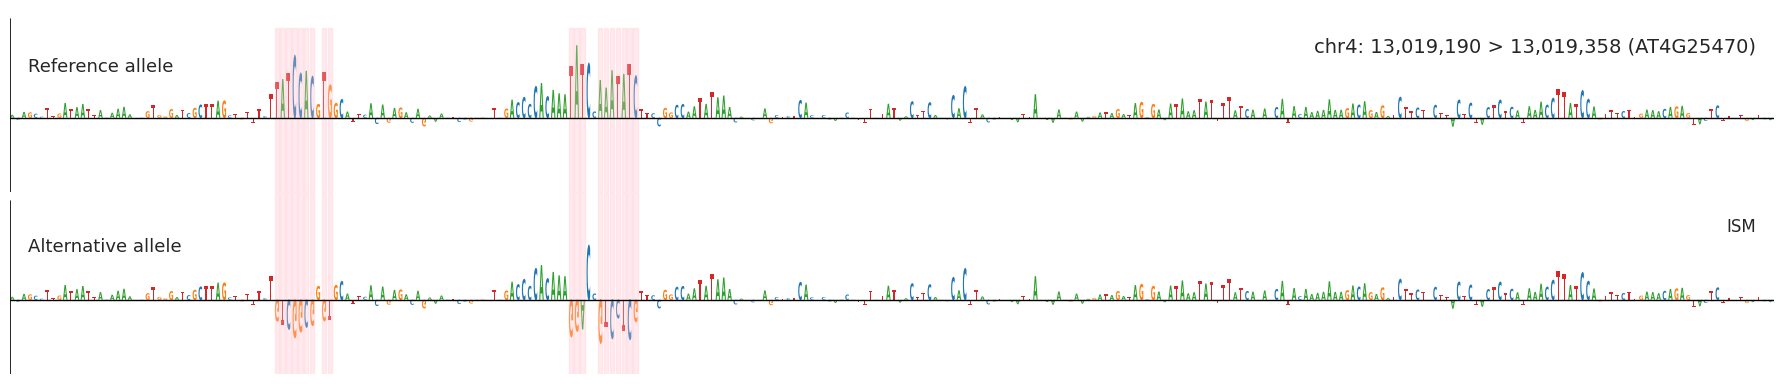

In [77]:
#results_df = pd.read_csv(f"/s/chromatin/a/nobackup/ahmed/DeepPlant/results/ISM/{gene}_new.csv")
loss_df = results_df.loc[
    (results_df.chip_peak_overlap == True) &
    (results_df.effect == 'Loss')
]

#loss_df = loss_df.loc[(loss_df.relative_position<1500)&(loss_df.relative_position>900)]

plot_ref_alt_ism(
    gene=gene,
    chrom='chr4',
    sum_lfc=sum_lfc[:,:,280],
    ref_sequence=ref_allele,
    results_df=loss_df,
    start=1100,
    end=1400
)

In [78]:
gex_metadata.iloc[281]

Sample                  SRX1881841
SampleName           Cold 24 hours
Tissue                      leaves
Ecotype                      Col-0
Genotype                        --
Treatment                     cold
Project                PRJNA324514
TotalReads                43221967
UniqueMappedRatio           0.8688
ReleaseDate              2016/8/26
Name: 281, dtype: object

In [79]:
results_df = analyze_mutations_with_chip(
    gene=gene,
    sum_lfc=sum_lfc[:,:,281],
    ref_sequence=ref_allele,
    nuclt=nuclt,
    gene_df_full=gene_df_full,
    motif_dict=pssm_dict_jaspar,
    metadata=metadata,
    bed_files_path=bed_files_path,
    mutation_threshold=0.4,
    score_threshold=0.8,
    pad=10
)
results_df.to_csv(f"/s/chromatin/a/nobackup/ahmed/DeepPlant/results/ISM/{gene}_cold_24h.csv",index=False)
results_df.head()

,gene,chromosome,relative_position,genomic_position,strand,ref,alt,motif,effect,chip_peak_overlap
0,AT4G25470,Chr4,1145,13016340,-1,T,G,NID1,Loss,No bed file found
1,AT4G25470,Chr4,1145,13016340,-1,T,G,GATA4,Gain,False
2,AT4G25470,Chr4,1145,13016340,-1,T,G,GATA15,Gain,False
3,AT4G25470,Chr4,1145,13016340,-1,T,G,AT5G04760,Loss,True
4,AT4G25470,Chr4,1145,13016340,-1,T,G,GATA8,Gain,No bed file found


In [80]:
results_df.loc[results_df.chip_peak_overlap==True]

,gene,chromosome,relative_position,genomic_position,strand,ref,alt,motif,effect,chip_peak_overlap
3,AT4G25470,Chr4,1145,13016340,-1,T,G,AT5G04760,Loss,True
10,AT4G25470,Chr4,1146,13016339,-1,A,T,AT5G04760,Loss,True
20,AT4G25470,Chr4,1147,13016338,-1,T,C,AT5G04760,Loss,True
27,AT4G25470,Chr4,1148,13016337,-1,C,G,AT5G04760,Loss,True
45,AT4G25470,Chr4,1149,13016336,-1,C,G,AT5G04760,Loss,True
...,...,...,...,...,...,...,...,...,...,...
305,AT4G25470,Chr4,1367,13016118,-1,C,A,AT5G04760,Loss,True
307,AT4G25470,Chr4,1367,13016118,-1,C,A,AT1G74840,Loss,True
309,AT4G25470,Chr4,1367,13016118,-1,C,A,AT5G56840,Loss,True
310,AT4G25470,Chr4,1367,13016118,-1,C,A,AT1G19000,Loss,True


In [81]:
results_df.relative_position.unique()

array([1145, 1146, 1147, 1148, 1149, 1150, 1151, 1153, 1154, 1189, 1190,
       1195, 1196, 1197, 1200, 1201, 1202, 1203, 1204, 1205, 1206, 1262,
       1363, 1364, 1367])

1145 ['G']
1146 ['T']
1147 ['C']
1148 ['G']
1149 ['G', 'G', 'G', 'G', 'G', 'G', 'G']
1150 ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C']
1151 ['G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G']
1153 ['G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G']
1154 ['T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'T']
1195 ['G']
1196 ['G']
1197 ['A']
1200 ['G', 'G']
1201 ['T', 'T']
1202 ['C', 'C']
1203 ['C', 'C', 'C']
1204 ['T', 'T', 'T']
1205 ['C', 'C', 'C']
1206 ['G', 'G', 'G']
1363 ['G', 'G', 'G', 'G', 'G']
1364 ['A', 'A', 'A', 'A', 'A']
1367 ['A', 'A', 'A', 'A', 'A']


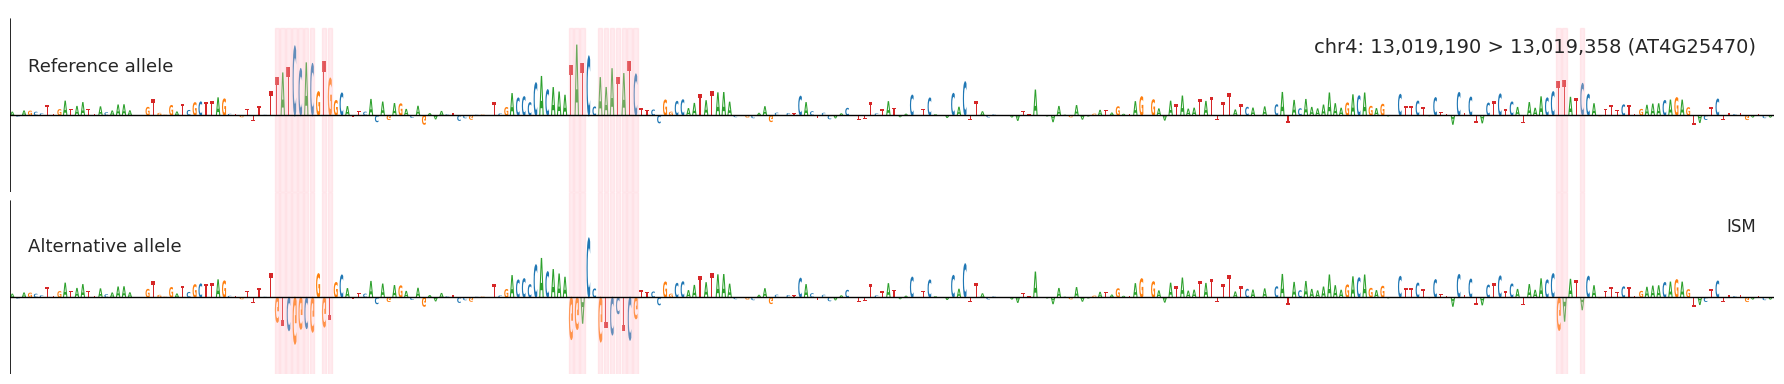

In [82]:
#results_df = pd.read_csv(f"/s/chromatin/a/nobackup/ahmed/DeepPlant/results/ISM/{gene}_new.csv")
loss_df = results_df.loc[
    (results_df.chip_peak_overlap == True) &
    (results_df.effect == 'Loss')
]

#loss_df = loss_df.loc[(loss_df.relative_position<1500)&(loss_df.relative_position>900)]

plot_ref_alt_ism(
    gene=gene,
    chrom='chr4',
    sum_lfc=sum_lfc[:,:,281],
    ref_sequence=ref_allele,
    results_df=loss_df,
    start=1100,
    end=1400
)